# **Section 1: Import**

## **Import & Define**

In [ ]:
# INSTALL PACKAGES
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip', 'setuptools'])

packages = [
    'yfinance', 'PyPortfolioOpt', 'scikit-learn', 'statsmodels',
    'scipy', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'openpyxl'
]

for pkg in packages:
    try:
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', pkg],
            capture_output=True, text=True, check=True
        )
    except subprocess.CalledProcessError as e:
        raise
    except Exception as e:
        raise

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import io

from sklearn.covariance import ShrunkCovariance, empirical_covariance, log_likelihood
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression

from scipy import linalg
from scipy.stats import linregress, gaussian_kde
import scipy.stats as stats

import statsmodels.api as sm
from collections import OrderedDict

from pypfopt import (
    black_litterman, risk_models,
    BlackLittermanModel, plotting,
    EfficientFrontier, objective_functions
)
from pypfopt.risk_models import CovarianceShrinkage

import random
import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [ ]:
# TICKERS DEFINITION
tickers_dict = {
    "Financials": ["TCB.VN", "VCB.VN"],
    "Materials": ["HPG.VN"],
    "Consumer Discretionary": ["MWG.VN"],
    "Real Estate": ["SIP.VN", "KBC.VN"]
}

equity_tickers = [t for sector in tickers_dict.values() for t in sector]
print(f"Total equity tickers: {len(equity_tickers)}")
print("Tickers:", equity_tickers)

sector_bounds = {
    "Financials": (0.35, 0.45),
    "Materials": (0, 0.1),
    "Consumer Discretionary": (0.25, 0.35),
    "Real Estate": (0, 0.1)
}

INITIAL_CAPITAL     = 10000000000
EQUITY_WEIGHT       = 0.90
CASH_WEIGHT         = 0.1
REBALANCE_THRESHOLD = 0.05

# Fee Structure
SALES_CHARGE_BUY                 = 0.0015
REDEMPTION_FEE                   = 0.0015
SECURITIES_SELLING_TAX           = 0.0010

ANNUAL_MGMT_FEE_NO_OUTPERFORMANCE  = 0.011
ANNUAL_MGMT_FEE_OUTPERFORMANCE     = 0.014
ANNUAL_MGMT_FEE                    = ANNUAL_MGMT_FEE_NO_OUTPERFORMANCE

print(f"\nInitial Capital  : {INITIAL_CAPITAL:,.0f} VND")
print(f"Equity allocation: {EQUITY_WEIGHT*100:.0f}%")
print(f"Cash allocation  : {CASH_WEIGHT*100:.0f}%")
print(f"Rebalance trigger: \u00b1{REBALANCE_THRESHOLD*100:.0f}% drift")
print(f"Sales Charge Buy : {SALES_CHARGE_BUY*100:.2f}%")
print(f"Redemption Fee   : {REDEMPTION_FEE*100:.2f}%")
print(f"Securities Selling Tax: {SECURITIES_SELLING_TAX*100:.2f}%")
print(f"Annual Management Fee (no outperformance): {ANNUAL_MGMT_FEE_NO_OUTPERFORMANCE*100:.2f}%")
print(f"Annual Management Fee (with outperformance): {ANNUAL_MGMT_FEE_OUTPERFORMANCE*100:.2f}%")

Total equity tickers: 6
Tickers: ['TCB.VN', 'VCB.VN', 'HPG.VN', 'MWG.VN', 'SIP.VN', 'KBC.VN']

Initial Capital  : 10,000,000,000 VND
Equity allocation: 90%
Cash allocation  : 10%
Rebalance trigger: ±5% drift
Sales Charge Buy : 0.15%
Redemption Fee   : 0.15%
Securities Selling Tax: 0.10%
Annual Management Fee (no outperformance): 1.10%
Annual Management Fee (with outperformance): 1.40%


In [ ]:
# RISK MANAGEMENT CONSTANTS

# Level 1: Position-level
STOP_LOSS_LIGHT      = 0.07
STOP_LOSS_HEAVY      = 0.10

# Level 2: Portfolio-level
NAV_DRAWDOWN_EMERGENCY = 0.10
EMERGENCY_CASH_TARGET  = 0.70
GOVBOND_RATE           = 0.11

print('Risk Management Constants loaded:')
print(f'  Stop-Loss (nhẹ):  -{STOP_LOSS_LIGHT*100:.0f}% từ giá mua → Bán 50%')
print(f'  Stop-Loss (nặng): -{STOP_LOSS_HEAVY*100:.0f}% từ giá mua → Bán 100%')
print(f'  NAV Emergency:    -{NAV_DRAWDOWN_EMERGENCY*100:.0f}% NAV → Cash {EMERGENCY_CASH_TARGET*100:.0f}% equity → Gov Bond')
print(f'  Gov Bond Rate:    {GOVBOND_RATE*100:.1f}%/năm (NHTM, gửi tới hết kỳ quản lý)')

Risk Management Constants loaded:
  Stop-Loss (nhẹ):  -7% từ giá mua → Bán 50%
  Stop-Loss (nặng): -10% từ giá mua → Bán 100%
  NAV Emergency:    -10% NAV → Cash 70% equity → Gov Bond
  Gov Bond Rate:    11.0%/năm (NHTM, gửi tới hết kỳ quản lý)


In [ ]:
# DEFINE UTILITIES
class DataProcessor:
    """Converts price series to returns."""

    @staticmethod
    def return_from_prices(prices, log_returns=False):
        if log_returns:
            return np.log(1 + prices.pct_change()).dropna(how='all')
        return prices.pct_change().dropna(how='all')


class VcvEstimation:
    """Ledoit-Wolf / Shrinkage covariance helpers (mirrors utils.py)."""

    @staticmethod
    def get_number_of_features(dict_data):
        return sum(len(v) for v in dict_data.values())

    @staticmethod
    def color_matrix(num_features):
        return np.random.randn(num_features, num_features)

    @staticmethod
    def shrinkage_factor():
        return np.logspace(-2, 0, 32)

    @staticmethod
    def negative_log_likelihood(shrinkage_factor, train, test):
        return [-ShrunkCovariance(shrinkage=s).fit(train).score(test) for s in shrinkage_factor]

    @staticmethod
    def real_covariance(color_matrix):
        return np.dot(color_matrix.T, color_matrix)

    @staticmethod
    def log_real_likelihood(empirical_cov, real_cov):
        return -log_likelihood(empirical_cov, linalg.inv(real_cov))

    @staticmethod
    def get_optimal_shrinkage_coefficient(tuned_parameters, train):
        cv = GridSearchCV(ShrunkCovariance(), tuned_parameters)
        cv.fit(train)
        return cv, cv.best_estimator_.shrinkage


class BlackLittermanHelper:
    """Black-Litterman helper (mirrors utils.py BlackLitterman class)."""

    def get_target_prices(self):
        """Returns a pre-loaded target price Series (integrated from target_price.xlsx)."""
        data = {
    'TCB.VN': 39028.715,
    'VCB.VN': 75000,
    'HPG.VN': 32670.12,
    'MWG.VN': 96361.5,
    'SIP.VN': 60000,
    'KBC.VN': 38000
        }
        return pd.Series(data)

    @staticmethod
    def get_confidences(view_dict):
        """Assigns confidence levels based on magnitude of analyst view (mirrors utils.py logic)."""
        def calc_conf(v):
            if abs(v) > 0.3:
                return random.choice([0.7, 0.8, 0.9])
            elif abs(v) > 0.1:
                return random.choice([0.4, 0.5, 0.6])
            else:
                return random.choice([0.1, 0.2, 0.3])
        return [calc_conf(r) for r in view_dict.values()]


class FamaFrenchHelper:
    """Loads and parses the Fama-French CSV (mirrors utils.py FamaFrench class)."""

    @staticmethod
    def get_factors(filepath):
        """
        Load FF daily factors from a local CSV file.
        USAGE: Pass the full path to F-F_Research_Data_Factors_daily.CSV
        """
        df = pd.read_csv(filepath)
        df = df.rename(columns={'Unnamed: 0': 'Date'})
        if len(str(df['Date'].iloc[0])) == 6:
            df['Date'] = df['Date'].apply(lambda x: pd.to_datetime(str(x), format='%Y%m'))
        else:
            df['Date'] = df['Date'].apply(lambda x: pd.to_datetime(str(x), format='%Y%m%d'))
        df = df.set_index('Date')
        df = df / 100
        return df

## **Data Download**

In [ ]:
# PRICE (for weighting)
ALLOC_START = '2022-04-30'
ALLOC_END   = '2026-04-30'

raw = yf.download(equity_tickers, start=ALLOC_START, end=ALLOC_END, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    prices_alloc = raw['Close']
else:
    prices_alloc = raw[['Close']]

prices_alloc.ffill(inplace=True)
prices_alloc.bfill(inplace=True)

print(f"Date range in data: {prices_alloc.index[0].date()} → {prices_alloc.index[-1].date()}")
prices_alloc.tail(3)

Date range in data: 2022-05-04 → 2026-04-29


Ticker,HPG.VN,KBC.VN,MWG.VN,SIP.VN,TCB.VN,VCB.VN
Date,,,,,,
2026-04-24,27399.101562,34200.0,83500.0,56211.867188,34250.0,60600.0
2026-04-28,27251.794922,34000.0,85600.0,56584.746094,34600.0,59800.0
2026-04-29,27251.794922,33900.0,84000.0,56584.746094,33850.0,59800.0


In [ ]:
# MARKET CAPITAL (for weighting)
caps_dict = {}
for ticker in equity_tickers:
    try:
        info = yf.Ticker(ticker).info
        if 'currency' in info:
            print(f"Currency for {ticker}: {info['currency']}")
        shares = info.get('sharesOutstanding', None)
        last_price = prices_alloc[ticker].dropna().iloc[-1]
        if shares:
            caps_dict[ticker] = last_price * shares
        else:
            caps_dict[ticker] = info.get('marketCap', np.nan)
    except Exception as e:
        print(f"  ⚠️  {ticker}: {e}")
        caps_dict[ticker] = np.nan

caps_series = pd.Series(caps_dict).dropna()
print("\nMarket Caps (VND):")
print(caps_series.apply(lambda x: f"{x/1e12:,.1f} nghìn tỷ VND"))

Currency for TCB.VN: VND
Currency for VCB.VN: VND
Currency for HPG.VN: VND
Currency for MWG.VN: VND
Currency for SIP.VN: VND
Currency for KBC.VN: VND

Market Caps (VND):
TCB.VN    239.9 nghìn tỷ VND
VCB.VN    499.7 nghìn tỷ VND
HPG.VN    209.2 nghìn tỷ VND
MWG.VN    123.3 nghìn tỷ VND
SIP.VN     13.7 nghìn tỷ VND
KBC.VN     31.9 nghìn tỷ VND
dtype: object


In [ ]:
# RISK-FREE RATE (for weighting)
risk_free_rate = 0.04204
print(f"Risk-free rate: {risk_free_rate:.4%}")

Risk-free rate: 4.2040%


# **Section 2: Portfolio Construction**

## **VCV Estimation**

In [ ]:
# LOG RETURNS
log_returns = DataProcessor.return_from_prices(prices_alloc, log_returns=True)
log_returns.dropna(inplace=True)
log_returns.describe().round(6)

Ticker,HPG.VN,KBC.VN,MWG.VN,SIP.VN,TCB.VN,VCB.VN
count,995.000000,995.000000,995.000000,995.000000,995.000000,995.000000
mean,0.000126,0.000095,0.000581,0.000284,0.000569,0.000287
std,0.021139,0.019755,0.017641,0.018808,0.020792,0.015534
min,-0.072571,-0.072321,-0.072278,-0.072477,-0.072534,-0.072571
25%,-0.009785,-0.005151,-0.003782,-0.004781,-0.008955,-0.007357
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.010318,0.005608,0.006349,0.005441,0.010216,0.006689
max,0.067139,0.067638,0.067606,0.067441,0.067579,0.067340


In [ ]:
# QUANTILE SCALING & TRAIN/TEST SPLIT
scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
scaled_df = pd.DataFrame(
    scaler.fit_transform(prices_alloc),
    columns=prices_alloc.columns,
    index=prices_alloc.index
)

# Train = first 80%, Test = last 20%
split_date = prices_alloc.index[int(len(prices_alloc) * 0.8)]
base_X_train = scaled_df.loc[:split_date]
base_X_test  = scaled_df.loc[split_date:]

In [ ]:
# RANDOM COLOR MATRIX TRANSFORMATION
num_features = len(equity_tickers)
colorMatrix = VcvEstimation.color_matrix(num_features)

X_train = np.dot(base_X_train, colorMatrix)
X_test  = np.dot(base_X_test,  colorMatrix)

In [ ]:
# OPTIMAL SHRINKAGE COEFFICIENT
vcv_est = VcvEstimation()
shrinkageFactor      = vcv_est.shrinkage_factor()
negative_logliks     = vcv_est.negative_log_likelihood(shrinkageFactor, X_train, X_test)
realCovariance       = vcv_est.real_covariance(colorMatrix)
empiricalCovariance  = empirical_covariance(X_train)
logRealLikelihood    = vcv_est.log_real_likelihood(empiricalCovariance, realCovariance)

tunedParameters = [{"shrinkage": shrinkageFactor}]
cv, optimal_shrinkage_coef = vcv_est.get_optimal_shrinkage_coefficient(tunedParameters, X_train)

In [ ]:
# VCV MATRIX
from sklearn.covariance import ShrunkCovariance

shrunk_cov_sklearn = ShrunkCovariance(shrinkage=optimal_shrinkage_coef).fit(log_returns).covariance_
cov_matrix = pd.DataFrame(shrunk_cov_sklearn, index=log_returns.columns, columns=log_returns.columns)
print(cov_matrix)

Ticker    HPG.VN    KBC.VN    MWG.VN    SIP.VN    TCB.VN    VCB.VN
Ticker                                                            
HPG.VN  0.000446  0.000141  0.000138  0.000117  0.000235  0.000131
KBC.VN  0.000141  0.000390  0.000165  0.000197  0.000146  0.000071
MWG.VN  0.000138  0.000165  0.000311  0.000121  0.000137  0.000078
SIP.VN  0.000117  0.000197  0.000121  0.000353  0.000109  0.000055
TCB.VN  0.000235  0.000146  0.000137  0.000109  0.000431  0.000132
VCB.VN  0.000131  0.000071  0.000078  0.000055  0.000132  0.000242


## **Black-Litterman Optimization**

In [ ]:
# MARKET RISK AVERSION
# Load VNI data from the provided Excel file
file_path = '/content/Simplize_VNINDEX_PriceHistory_20260506 (1).xlsx'
try:
    vni_excel_data = pd.read_excel(file_path)
    if 'NGÀY' in vni_excel_data.columns and 'Close' in vni_excel_data.columns:
        market_prices = vni_excel_data.set_index('NGÀY')['Close']
        market_prices.index = pd.to_datetime(market_prices.index)
        market_prices = market_prices.sort_index()
        market_prices = market_prices.rename('^VNINDEX')
        market_prices = market_prices.loc[ALLOC_START:ALLOC_END]
        print("VNINDEX data loaded from Excel file:")
        print(market_prices.head())
        print(f"Market prices for VNINDEX successfully loaded from Excel. Data points: {len(market_prices)}")
    else:
        print("  ⚠️  'NGÀY' or 'Close' column not found in the Excel file. Please check the column names.")
        market_prices = pd.Series([])
except FileNotFoundError:
    print(f"  ⚠️  Error: The file '{file_path}' was not found. Please ensure the file is uploaded and the path is correct.")
    market_prices = pd.Series([])
except Exception as e:
    print(f"  ⚠️  An error occurred while reading the Excel file: {e}")
    market_prices = pd.Series([])

S = cov_matrix
# Calculate delta only if market_prices is not empty
if not market_prices.empty:
    delta = black_litterman.market_implied_risk_aversion(market_prices, risk_free_rate=risk_free_rate)
    print(f"Market risk aversion (λ): {delta:.4f}")
else:
    delta = np.nan
    print("Market risk aversion (λ): nan (Market prices data is missing or empty)")

VNINDEX data loaded from Excel file:
NGÀY
2022-05-04    1348.68
2022-05-05    1360.68
2022-05-06    1329.26
2022-05-09    1269.62
2022-05-10    1293.56
Name: ^VNINDEX, dtype: float64
Market prices for VNINDEX successfully loaded from Excel. Data points: 997
Market risk aversion (λ): 1.4610


In [ ]:
# MARKET IMPLIED-PRIOR RETURN
caps_for_bl = {t: caps_dict[t] for t in equity_tickers if t in caps_dict and not np.isnan(caps_dict.get(t, np.nan))}

market_prior = black_litterman.market_implied_prior_returns(caps_for_bl, delta, S, risk_free_rate)

print("Market-Implied Prior Returns (π):")
print(market_prior.round(4).to_string())

Market-Implied Prior Returns (π):
Ticker
HPG.VN    0.0424
KBC.VN    0.0422
MWG.VN    0.0422
SIP.VN    0.0422
TCB.VN    0.0424
VCB.VN    0.0423


In [ ]:
# ANALYST VIEWS FROM TARGET PRICES
bl_helper     = BlackLittermanHelper()
target_series = bl_helper.get_target_prices()

last_prices   = prices_alloc.iloc[-1]
common_tickers = [t for t in equity_tickers if t in target_series.index]
sorted_target  = target_series.reindex(last_prices.index)

expt_returns = (sorted_target - last_prices) / last_prices
viewdict = expt_returns.dropna().to_dict()

print("Analyst Views (expected returns from target prices):")
for k, v in viewdict.items():
    print(f"  {k:6s}: {v:+.2%}")

Analyst Views (expected returns from target prices):
  HPG.VN: +19.88%
  KBC.VN: +12.09%
  MWG.VN: +14.72%
  SIP.VN: +6.04%
  TCB.VN: +15.30%
  VCB.VN: +25.42%


In [ ]:
# CONFIDENCE LEVEL FOR EACH VIEW
confidences = BlackLittermanHelper.get_confidences(viewdict)

intervals = []
for conf in confidences:
    if conf >= 0.7:
        interval = (conf - 0.1, conf + 0.1)
    elif 0.4 <= conf <= 0.6:
        interval = (conf - 0.05, conf + 0.05)
    else:
        interval = (conf - 0.03, conf + 0.03)
    interval = (max(0, interval[0]), min(1, interval[1]))
    intervals.append(interval)

variances = [((ub - lb) / 2) ** 2 for lb, ub in intervals]
omega = np.diag(variances)

print("Confidences:", [round(c, 2) for c in confidences])
print("Omega diagonal (view uncertainties):", [round(v, 6) for v in variances])

Confidences: [0.6, 0.4, 0.6, 0.2, 0.4, 0.4]
Omega diagonal (view uncertainties): [0.0025, 0.0025, 0.0025, 0.0009, 0.0025, 0.0025]


In [ ]:
# FIT MODEL & EXTRACT POSTERIOR RETURNS
bl_tickers = [t for t in equity_tickers if t in caps_for_bl]
S_bl_input = cov_matrix.loc[bl_tickers, bl_tickers]
viewdict_bl = {k: v for k, v in viewdict.items() if k in bl_tickers}
confidences_bl = BlackLittermanHelper.get_confidences(viewdict_bl)

intervals_bl = []
for conf in confidences_bl:
    if conf >= 0.7:
        iv = (conf - 0.1, conf + 0.1)
    elif 0.4 <= conf <= 0.6:
        iv = (conf - 0.05, conf + 0.05)
    else:
        iv = (conf - 0.03, conf + 0.03)
    iv = (max(0, iv[0]), min(1, iv[1]))
    intervals_bl.append(iv)

variances_bl = [((ub - lb) / 2) ** 2 for lb, ub in intervals_bl]
omega_bl = np.diag(variances_bl)

bl = BlackLittermanModel(
    S_bl_input,
    pi="market",
    market_caps={t: caps_for_bl[t] for t in bl_tickers},
    risk_aversion=delta,
    absolute_views=viewdict_bl,
    omega=omega_bl
)

ret_bl   = bl.bl_returns()
S_bl     = bl.bl_cov()

print(ret_bl.round(4))

Ticker
TCB.VN    0.0043
VCB.VN    0.0029
HPG.VN    0.0045
MWG.VN    0.0032
SIP.VN    0.0031
KBC.VN    0.0035
dtype: float64


In [ ]:
# OPTIMAL WEIGHT
rets_df = pd.DataFrame(
    [market_prior.reindex(bl_tickers), ret_bl, pd.Series(viewdict_bl).reindex(bl_tickers)],
    index=["Prior (Market)", "Posterior (BL)", "Views (Analyst)"]
).T

ef = EfficientFrontier(ret_bl, S_bl)

ef.add_constraint(lambda w: w >= 0.00)


ef.add_objective(objective_functions.L2_reg)
daily_risk_free_rate = (1 + risk_free_rate)**(1/252) - 1
ef.max_sharpe(risk_free_rate=daily_risk_free_rate)
raw_weights = ef.clean_weights()

weights = {k: v for k, v in raw_weights.items() if v > 1e-4}

print("Optimal equity weights (non-zero):")
for t, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {t:6s}: {w:.4f}  ({w*100:.2f}%)")
print(f"  Sum: {sum(weights.values()):.4f}")
print(f"Total number of tickers: {len(weights)}")

Optimal equity weights (non-zero):
  HPG.VN: 0.2110  (21.10%)
  TCB.VN: 0.1989  (19.89%)
  KBC.VN: 0.1638  (16.38%)
  MWG.VN: 0.1474  (14.74%)
  SIP.VN: 0.1439  (14.39%)
  VCB.VN: 0.1348  (13.48%)
  Sum: 1.0000
Total number of tickers: 6


In [ ]:
# SUMMARY
ticker_to_sector = {t: s for s, tlist in tickers_dict.items() for t in tlist}

rows = []
for ticker, w in weights.items():
    sector  = ticker_to_sector.get(ticker, "Unknown")
    excess  = ret_bl.get(ticker, np.nan)
    total   = excess + risk_free_rate if not np.isnan(excess) else np.nan
    rows.append({
        'Sector': sector,
        'Ticker': ticker,
        'BL Expected Excess Return': excess,
        'BL Expected Return': total,
        'BL Optimal Weight': w
    })

bl_weights_table = pd.DataFrame(rows).sort_values(['Sector', 'BL Optimal Weight'], ascending=[True, False])
bl_weights_table = bl_weights_table.reset_index(drop=True)

sector_subtotals = bl_weights_table.groupby('Sector')['BL Optimal Weight'].sum().reset_index()
sector_subtotals.columns = ['Sector', 'Sector Weight']

bl_weights_table = bl_weights_table.merge(sector_subtotals, on='Sector', how='left')
bl_weights_table = bl_weights_table[['Sector', 'Sector Weight', 'Ticker',
                                      'BL Expected Excess Return', 'BL Expected Return', 'BL Optimal Weight']]

display_table = bl_weights_table.copy()

print("Optimal Weights using Black-Litterman Absolute Views")
from IPython.display import display as ipy_display
ipy_display(display_table)

Optimal Weights using Black-Litterman Absolute Views


,Sector,Sector Weight,Ticker,BL Expected Excess Return,BL Expected Return,BL Optimal Weight
0,Consumer Discretionary,0.14739,MWG.VN,0.003193,0.045233,0.14739
1,Financials,0.33380,TCB.VN,0.004253,0.046293,0.19895
2,Financials,0.33380,VCB.VN,0.002934,0.044974,0.13485
3,Materials,0.21102,HPG.VN,0.004501,0.046541,0.21102
4,Real Estate,0.30778,KBC.VN,0.003531,0.045571,0.16385
5,Real Estate,0.30778,SIP.VN,0.003122,0.045162,0.14393


## **Portfolio Theory**

### **Traditional Approach (Fama-French 3-Factor Model)**

In [ ]:
# IMPORT DATA
def load_ff_daily_factors(source=None):
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"

    def _parse_csv_bytes(csv_bytes):
        raw = csv_bytes.decode("utf-8", errors="ignore").splitlines()
        start_idx = None
        for i, line in enumerate(raw):
            if line[:8].isdigit():
                start_idx = i
                break
        if start_idx is None:
            raise ValueError("Cannot locate factor data rows.")

        df = pd.read_csv(io.StringIO("\n".join(raw[start_idx:])))
        first_col = df.columns[0]
        if first_col != "Date":
            df = df.rename(columns={first_col: "Date"})
        df = df[pd.to_numeric(df["Date"], errors="coerce").notna()].copy()
        df["Date"] = pd.to_datetime(df["Date"].astype(int).astype(str), format="%Y%m%d")
        df = df.set_index("Date")
        df = df.apply(pd.to_numeric, errors="coerce") / 100.0
        return df

    try:
        import requests
        import zipfile
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            name = zf.namelist()[0]
            csv_bytes = zf.read(name)
        return _parse_csv_bytes(csv_bytes)
    except Exception:
        pass

    if source is None:
        source = FAMA_FRENCH_LOCAL_PATH

    if source is None or not os.path.exists(source):
        raise FileNotFoundError(
            "Không tải được từ Internet và cũng không thấy file local. "
            "Hãy dán path đúng của F-F_Research_Data_Factors_daily.CSV vào biến FAMA_FRENCH_LOCAL_PATH."
        )

    df = pd.read_csv(source)
    if df.columns[0] != "Date":
        df = df.rename(columns={df.columns[0]: "Date"})
    df = df[pd.to_numeric(df["Date"], errors="coerce").notna()].copy()
    df["Date"] = pd.to_datetime(df["Date"].astype(int).astype(str), format="%Y%m%d")
    df = df.set_index("Date")
    df = df.apply(pd.to_numeric, errors="coerce") / 100.0
    return df

FAMA_FRENCH_LOCAL_PATH = None
ff_factors_daily = load_ff_daily_factors()
ff_factors_daily.head()

,0.09,-0.25,-0.27,0.01
Date,,,,
1926-07-02,0.0045,-0.0033,-0.0006,0.0001
1926-07-06,0.0017,0.0030,-0.0039,0.0001
1926-07-07,0.0009,-0.0058,0.0002,0.0001
1926-07-08,0.0022,-0.0038,0.0019,0.0001
1926-07-09,-0.0071,0.0043,0.0057,0.0001


In [ ]:
# FAMA-FRENCH 3-FACTOR MODEL
if 'ff_factors_daily' in locals() and not ff_factors_daily.empty:
    print(f"Fama-French factors loaded (from previous cell): {ff_factors_daily.shape}")
    print(f"Date range: {ff_factors_daily.index[0]} → {ff_factors_daily.index[-1]}")
    ff_loaded = True
else:
    print("Fama-French factors not found from previous cell. Creating synthetic FF factors for demonstration.")
    dates = log_returns.index
    ff_factors_daily = pd.DataFrame({
        'Mkt-RF': np.random.normal(0.0004, 0.008, len(dates)),
        'SMB':    np.random.normal(0.0001, 0.004, len(dates)),
        'HML':    np.random.normal(0.0001, 0.004, len(dates)),
        'RF':     np.full(len(dates), risk_free_rate / 252),
    }, index=dates)
    ff_loaded = False

Fama-French factors loaded (from previous cell): (26211, 4)
Date range: 1926-07-02 00:00:00 → 2026-03-31 00:00:00


In [ ]:
# PORTFOLIO RETURNS
weights_series = pd.Series(weights)

common = [t for t in weights_series.index if t in log_returns.columns]
portfolio_log = log_returns[common]
ws = weights_series.reindex(common)
ws = ws / ws.sum()

portfolio_returns = portfolio_log.mul(ws, axis=1).sum(axis=1)
monthly_portfolio_returns = portfolio_returns.resample('ME').sum()
monthly_portfolio_returns.index = monthly_portfolio_returns.index.to_period('M')

print("Monthly portfolio returns (calibration period):")
print(monthly_portfolio_returns.round(4).to_string())

Monthly portfolio returns (calibration period):
Date
2022-05   -0.0664
2022-06   -0.0539
2022-07    0.0048
2022-08    0.0355
2022-09   -0.0718
2022-10   -0.1189
2022-11    0.0575
2022-12   -0.0067
2023-01    0.0876
2023-02   -0.0394
2023-03    0.0186
2023-04    0.0150
2023-05    0.0037
2023-06    0.0680
2023-07    0.0664
2023-08    0.0020
2023-09   -0.0456
2023-10   -0.1800
2023-11    0.0964
2023-12    0.0513
2024-01    0.0560
2024-02    0.0954
2024-03    0.0659
2024-04   -0.0641
2024-05    0.0803
2024-06   -0.0224
2024-07   -0.0146
2024-08    0.0049
2024-09    0.0088
2024-10   -0.0054
2024-11   -0.0008
2024-12    0.0127
2025-01    0.0076
2025-02    0.0381
2025-03    0.0033
2025-04   -0.1219
2025-05    0.0684
2025-06    0.0475
2025-07    0.0723
2025-08    0.1124
2025-09   -0.0378
2025-10   -0.0237
2025-11   -0.0144
2025-12    0.0103
2026-01    0.0628
2026-02    0.0114
2026-03   -0.1009
2026-04    0.0426
Freq: M


In [ ]:
# OLS REGRESSION
ff_sub = ff_factors_daily[ff_factors_daily.index.isin(portfolio_returns.index)].copy()

expected_ff_cols = ['Mkt-RF', 'SMB', 'HML', 'RF']

if not all(col in ff_sub.columns for col in expected_ff_cols):
    current_cols = ff_sub.columns.tolist()
    if len(current_cols) == 4:
        ff_sub.rename(columns={
            current_cols[0]: 'Mkt-RF',
            current_cols[1]: 'SMB',
            current_cols[2]: 'HML',
            current_cols[3]: 'RF'
        }, inplace=True)

ff_sub["Excess_Return"] = portfolio_returns - ff_sub["RF"]
ff_sub_monthly = ff_sub.resample('ME').sum()

X = sm.add_constant(ff_sub_monthly[["Mkt-RF", "SMB", "HML"]])
y = ff_sub_monthly["Excess_Return"]
ff_model = sm.OLS(y, X).fit()

print(ff_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     3.158
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0342
Time:                        01:44:50   Log-Likelihood:                 68.231
No. Observations:                  47   AIC:                            -128.5
Df Residuals:                      43   BIC:                            -121.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0016      0.009     -0.176      0.8

In [ ]:
# SUMMARY
ann_return_trad = portfolio_returns.mean() * 252
ann_std_trad = portfolio_returns.std() * np.sqrt(252)
sharpe_trad = (ann_return_trad - risk_free_rate) / ann_std_trad

cumulative_returns_trad = (1 + portfolio_returns).prod() - 1

downside_returns_trad = portfolio_returns[portfolio_returns < 0]
downside_std_trad = downside_returns_trad.std() * np.sqrt(252)
sortino_trad = (ann_return_trad - risk_free_rate) / downside_std_trad if downside_std_trad > 0 else np.nan

traditional_metrics = pd.DataFrame({
    'Backtest': [
        f'{ann_return_trad:.4%}',
        f'{cumulative_returns_trad:.4%}',
        f'{ann_std_trad:.4%}',
        f'{sharpe_trad:.4f}',
        f'{sortino_trad:.4f}'
    ]
}, index=['Annual Return', 'Cumulative Returns', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio'])

print("Performance Results Summary")
display(traditional_metrics)

Performance Results Summary


,Backtest
Annual Return,8.0772%
Cumulative Returns,25.6207%
Annual Volatility,21.3792%
Sharpe Ratio,0.1812
Sortino Ratio,0.2222


### **Modern Approach (Algorithmic Trading)**

In [ ]:
# DATA MODEL
ff_factors_subset2 = ff_factors_daily[
    ff_factors_daily.index.isin(portfolio_returns.index)
].copy()

if all(col in ff_factors_subset2.columns for col in ['    0.09', '   -0.25', '   -0.27', '    0.01']):
    ff_factors_subset2.rename(columns={
        '    0.09': 'Mkt-RF',
        '   -0.25': 'SMB',
        '   -0.27': 'HML',
        '    0.01': 'RF'
    }, inplace=True)

ff_factors_subset2["Returns"] = portfolio_returns
ff_factors_subset2.drop(columns=["RF"], inplace=True)
ff_factors_subset2

,Mkt-RF,SMB,HML,Returns
Date,,,,
2022-05-05,-0.0380,-0.0079,0.0237,0.004917
2022-05-06,-0.0085,-0.0134,0.0184,-0.009153
2022-05-09,-0.0352,-0.0051,0.0133,-0.026537
2022-05-10,0.0022,-0.0022,-0.0122,0.010091
2022-05-11,-0.0193,-0.0113,0.0261,-0.000787
...,...,...,...,...
2026-03-25,0.0063,0.0069,0.0008,0.026321
2026-03-26,-0.0173,0.0007,0.0125,-0.012757
2026-03-27,-0.0174,-0.0029,0.0071,0.030126


In [ ]:
# FEATURES AND TARGET
X_algo = ff_factors_subset2.drop(['Returns'], axis=1)
y_algo = ff_factors_subset2.loc[:, 'Returns']

In [ ]:
# TRAIN-TEST SPLIT (80/20)
split = int(0.8 * len(X_algo))
X_train_algo = X_algo[:split]
X_test_algo  = X_algo[split:]
y_train_algo = y_algo[:split]
y_test_algo  = y_algo[split:]
test_returns = ff_factors_subset2["Returns"][split:]
test_returns

,Returns
Date,
2025-06-23,0.007236
2025-06-24,0.000971
2025-06-25,0.002208
2025-06-26,0.007164
2025-06-27,0.002064
...,...
2026-03-25,0.026321
2026-03-26,-0.012757
2026-03-27,0.030126


In [ ]:
# LINEAR REGRESSION PREDICTION MODEL
lin_reg_model = LinearRegression(fit_intercept=True)
lin_reg_model = lin_reg_model.fit(X_train_algo, y_train_algo)
predictions = lin_reg_model.predict(X_test_algo)

In [ ]:
# BUILD SIGNALS DATAFRAME
y_test_algo = y_test_algo.to_frame()

y_test_algo['Predictions'] = predictions
y_test_algo['Returns']     = test_returns

y_test_algo['Buy Signal'] = np.where(
    y_test_algo['Predictions'] > y_test_algo['Returns'], 1.0, 0.0
)

y_test_algo = y_test_algo.dropna()
y_test_algo.head()

,Returns,Predictions,Buy Signal
Date,,,
2025-06-23,0.007236,0.000977,0.0
2025-06-24,0.000971,0.000832,0.0
2025-06-25,0.002208,-0.000253,0.0
2025-06-26,0.007164,0.001348,0.0
2025-06-27,0.002064,0.000446,0.0


In [ ]:
import numpy as np
# GENERATE SIGNALS
def generate_signals(input_df, start_capital=100000, share_count=2000, annual_mgmt_fee=0.0):
    initial_capital = float(start_capital)
    signals_df = input_df.copy()
    share_size = share_count

    TRADING_DAYS = 252

    # Daily management fee rate
    mgmt_fee_daily_rate = (1 + annual_mgmt_fee)**(1/TRADING_DAYS) - 1 if annual_mgmt_fee > 0 else 0.0

    signals_df['Position'] = share_size * signals_df['Buy Signal']
    signals_df['Entry/Exit'] = signals_df['Buy Signal'].diff()
    signals_df['Entry/Exit Position'] = signals_df['Position'].diff()

    # Calculate portfolio total value based on initial capital and returns
    signals_df['Adjusted Daily Returns'] = signals_df['Returns'] - mgmt_fee_daily_rate

    # Calculate portfolio value after adjusting for returns and fees
    signals_df['Portfolio Total'] = initial_capital * (1 + signals_df['Adjusted Daily Returns']).cumprod()

    # Recalculate Portfolio Daily Returns after fees
    signals_df['Portfolio Daily Returns'] = signals_df['Portfolio Total'].pct_change()
    signals_df['Portfolio Cumulative Returns'] = \
        (1 + signals_df['Portfolio Daily Returns']).cumprod() - 1

    signals_df = signals_df.dropna()
    return signals_df

signals_df = generate_signals(y_test_algo, annual_mgmt_fee=ANNUAL_MGMT_FEE)
signals_df.head(10)

,Returns,Predictions,Buy Signal,Position,Entry/Exit,Entry/Exit Position,Adjusted Daily Returns,Portfolio Total,Portfolio Daily Returns,Portfolio Cumulative Returns
Date,,,,,,,,,,
2025-06-24,0.000971,0.000832,0.0,0.0,0.0,0.0,0.000928,100812.729797,0.000928,0.000928
2025-06-25,0.002208,-0.000253,0.0,0.0,0.0,0.0,0.002164,101030.901022,0.002164,0.003094
2025-06-26,0.007164,0.001348,0.0,0.0,0.0,0.0,0.007121,101750.301578,0.007121,0.010237
2025-06-27,0.002064,0.000446,0.0,0.0,0.0,0.0,0.002020,101955.880874,0.002020,0.012278
2025-06-30,0.003217,0.000287,0.0,0.0,0.0,0.0,0.003173,102279.409685,0.003173,0.015490
2025-07-01,-0.001229,0.002308,1.0,2000.0,1.0,2000.0,-0.001272,102149.294853,-0.001272,0.014198
2025-07-02,0.021166,0.001050,0.0,0.0,-1.0,-2000.0,0.021123,104306.962648,0.021123,0.035621
2025-07-03,-0.011330,0.000673,1.0,2000.0,1.0,2000.0,-0.011374,103120.585854,-0.011374,0.023842
2025-07-07,0.010254,-0.000778,0.0,0.0,-1.0,-2000.0,0.010211,104173.546505,0.010211,0.034296


In [ ]:
# ALGORITHMIC EVALUATION
def algo_evaluation(signals_df):
    metrics  = ['Annual Return','Cumulative Returns','Annual Volatility','Sharpe Ratio','Sortino Ratio']
    port_eval = pd.DataFrame(index=metrics, columns=['Backtest'])
    port_eval.loc['Cumulative Returns'] = signals_df['Portfolio Cumulative Returns'].iloc[-1] * 100
    port_eval.loc['Annual Return']      = signals_df['Portfolio Daily Returns'].mean() * 252 * 100
    port_eval.loc['Annual Volatility']  = signals_df['Portfolio Daily Returns'].std() * np.sqrt(252) * 100
    port_eval.loc['Sharpe Ratio']       = (
        signals_df['Portfolio Daily Returns'].mean() * 252
    ) / (signals_df['Portfolio Daily Returns'].std() * np.sqrt(252))
    sortino_df = signals_df[['Portfolio Daily Returns']].copy()
    sortino_df['Downside Returns'] = 0.0
    mask = sortino_df['Portfolio Daily Returns'] < 0
    sortino_df.loc[mask, 'Downside Returns'] = sortino_df['Portfolio Daily Returns'] ** 2
    down_stdev = np.sqrt(sortino_df['Downside Returns'].mean()) * np.sqrt(252)
    port_eval.loc['Sortino Ratio'] = (
        signals_df['Portfolio Daily Returns'].mean() * 252
    ) / down_stdev if down_stdev > 0 else np.nan
    return port_eval

algo_eval_result = algo_evaluation(signals_df)
algo_eval_result

,Backtest
Annual Return,13.22008
Cumulative Returns,7.720877
Annual Volatility,25.448383
Sharpe Ratio,0.519486
Sortino Ratio,0.698973


In [ ]:
# ALGO VS UNDERLYING COMPARISON
def underlying_evaluation(signals_df):
    underlying = pd.DataFrame()
    underlying['Returns'] = signals_df['Returns']
    underlying['Portfolio Daily Returns'] = underlying['Returns'].fillna(0)
    underlying['Portfolio Cumulative Returns'] = (
        (1 + underlying['Portfolio Daily Returns']).cumprod() - 1
    )
    return algo_evaluation(underlying)

def algo_vs_underlying(signals_df):
    metrics = ['Annual Return','Cumulative Returns','Annual Volatility','Sharpe Ratio','Sortino Ratio']
    comparison_df = pd.DataFrame(index=metrics, columns=['Algo','Underlying'])
    comparison_df['Algo']       = algo_evaluation(signals_df)['Backtest']
    comparison_df['Underlying'] = underlying_evaluation(signals_df)['Backtest']
    return comparison_df

algo_vs_underlying(signals_df)

,Algo,Underlying
Annual Return,13.22008,14.314097
Cumulative Returns,7.720877,8.603408
Annual Volatility,25.448383,25.448383
Sharpe Ratio,0.519486,0.562476
Sortino Ratio,0.698973,0.758131


In [ ]:
import numpy as np

# TRADE EVALUATION TABLE
def trade_evaluation(signals_df):
    trade_eval_df = pd.DataFrame(columns=[
        'Entry Date','Exit Date','Shares',
        'Entry Share Price','Exit Share Price',
        'Entry Portfolio Holding','Exit Portfolio Holding','Profit/Loss'
    ])

    entry_date = None
    entry_portfolio_holding = np.nan
    share_size = np.nan
    entry_share_price = np.nan

    rows = []
    for index, row in signals_df.iterrows():
        if row['Entry/Exit'] == 1:
            entry_date             = index
            entry_portfolio_holding = row['Portfolio Total']
            share_size             = row['Entry/Exit Position']
            entry_share_price      = row['Returns']
        elif row['Entry/Exit'] == -1:
            if pd.notna(entry_portfolio_holding):
                exit_date             = index
                exit_portfolio_holding = abs(row['Portfolio Total'])
                exit_share_price      = row['Returns']
                profit_loss           = exit_portfolio_holding - entry_portfolio_holding
                rows.append({
                    'Entry Date': entry_date, 'Exit Date': exit_date,
                    'Shares': share_size,
                    'Entry Share Price': entry_share_price,
                    'Exit Share Price': exit_share_price,
                    'Entry Portfolio Holding': entry_portfolio_holding,
                    'Exit Portfolio Holding': exit_portfolio_holding,
                    'Profit/Loss': profit_loss
                })
                # Reset entry variables after a trade is closed
                entry_date = None
                entry_portfolio_holding = np.nan
                share_size = np.nan
                entry_share_price = np.nan

    if rows:
        trade_eval_df = pd.DataFrame(rows)
    return trade_eval_df

trade_evaluation_df = trade_evaluation(signals_df)
trade_evaluation_df

,Entry Date,Exit Date,Shares,Entry Share Price,Exit Share Price,Entry Portfolio Holding,Exit Portfolio Holding,Profit/Loss
0,2025-07-01,2025-07-02,2000.0,-0.001229,0.021166,102149.294853,104306.962648,2157.667795
1,2025-07-03,2025-07-07,2000.0,-0.011330,0.010254,103120.585854,104173.546505,1052.960651
2,2025-07-15,2025-07-16,2000.0,-0.007686,0.009703,107683.668523,108723.799860,1040.131338
3,2025-07-21,2025-07-22,2000.0,-0.002815,0.005283,109171.596787,109743.650228,572.053442
4,2025-07-23,2025-07-24,2000.0,0.000338,0.006632,109775.940648,110499.231954,723.291306
5,2025-07-29,2025-07-30,2000.0,-0.037244,0.006882,107901.270047,108639.202119,737.932072
6,2025-08-01,2025-08-04,2000.0,-0.004184,0.014247,108501.433393,110042.580661,1541.147268
7,2025-08-08,2025-08-11,2000.0,-0.011924,0.005909,116533.711001,117217.284901,683.573900
8,2025-08-13,2025-08-14,2000.0,-0.004429,0.010303,117041.997575,118242.825095,1200.827520
9,2025-08-15,2025-08-18,2000.0,-0.019218,0.015077,115965.258288,117708.684701,1743.426413


In [ ]:
# UNDERLYING CUMULATIVE RETURNS
def underlying_returns(signals_df):
    underlying = pd.DataFrame()
    underlying['Returns'] = signals_df['Returns']
    underlying['Underlying Daily Returns'] = underlying['Returns'].fillna(0)
    underlying['Underlying Cumulative Returns'] = (
        (1 + underlying['Underlying Daily Returns']).cumprod() - 1
    )
    underlying['Algo Cumulative Returns'] = signals_df['Portfolio Cumulative Returns']
    return underlying[['Underlying Cumulative Returns', 'Algo Cumulative Returns']]

underlying_returns(signals_df)

,Underlying Cumulative Returns,Algo Cumulative Returns
Date,,
2025-06-24,0.000971,0.000928
2025-06-25,0.003181,0.003094
2025-06-26,0.010368,0.010237
2025-06-27,0.012453,0.012278
2025-06-30,0.015710,0.015490
...,...,...
2026-03-25,0.049630,0.041280
2026-03-26,0.036240,0.027951
2026-03-27,0.067457,0.058874


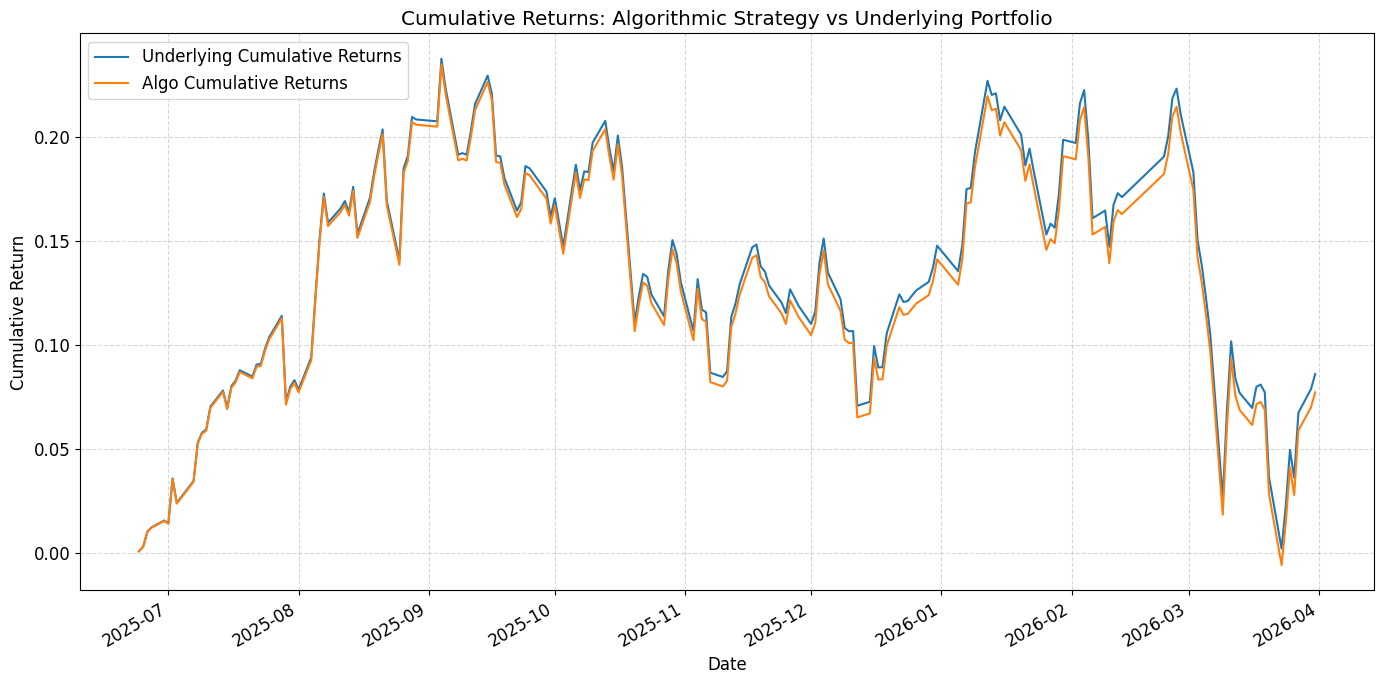

In [ ]:
# CUMULATIVE RETURN PLOT: ALGO vs UNDERLYING
underlying_returns(signals_df).plot(figsize=(14, 7),
    title='Cumulative Returns: Algorithmic Strategy vs Underlying Portfolio')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Risk Measurements / Estimations (VaR using Monte Carlo Simulation Method)**

In [ ]:
# YEARLY LOG RETURNS FOR VAR
yearly_log_returns = portfolio_log.resample('YE').sum()
yearly_log_returns

Ticker,TCB.VN,VCB.VN,HPG.VN,MWG.VN,SIP.VN,KBC.VN
Date,,,,,,
2022-12-31,-0.485359,0.001251,-0.584934,0.000000,0.000000,0.000000
2023-12-31,0.207156,0.170105,0.440045,-0.118563,-0.001828,0.028756
2024-12-31,0.500719,0.127285,0.047682,0.362253,0.430141,-0.154676
2025-12-31,0.373855,-0.051871,0.172896,0.385284,-0.289058,0.262081
2026-12-31,-0.030548,0.039221,0.049872,-0.051055,0.143228,-0.041883


In [ ]:
# VCV MATRIX ON YEARLY LOG RETURNS
from pypfopt.risk_models import CovarianceShrinkage as PfoptCovShrinkage

cov_estimator_var = PfoptCovShrinkage(
    yearly_log_returns, returns_data=True, frequency=1
)
vcv_matrix = cov_estimator_var.ledoit_wolf()
vcv_matrix

Ticker,TCB.VN,VCB.VN,HPG.VN,MWG.VN,SIP.VN,KBC.VN
Ticker,,,,,,
TCB.VN,0.078674,0.002765,0.027265,0.014430,0.004298,0.001041
VCB.VN,0.002765,0.043798,0.004018,-0.001772,0.003585,-0.002157
HPG.VN,0.027265,0.004018,0.076325,0.000892,-0.001840,0.002809
MWG.VN,0.014430,-0.001772,0.000892,0.055763,0.000286,0.001995
SIP.VN,0.004298,0.003585,-0.001840,0.000286,0.058417,-0.009355
KBC.VN,0.001041,-0.002157,0.002809,0.001995,-0.009355,0.047475


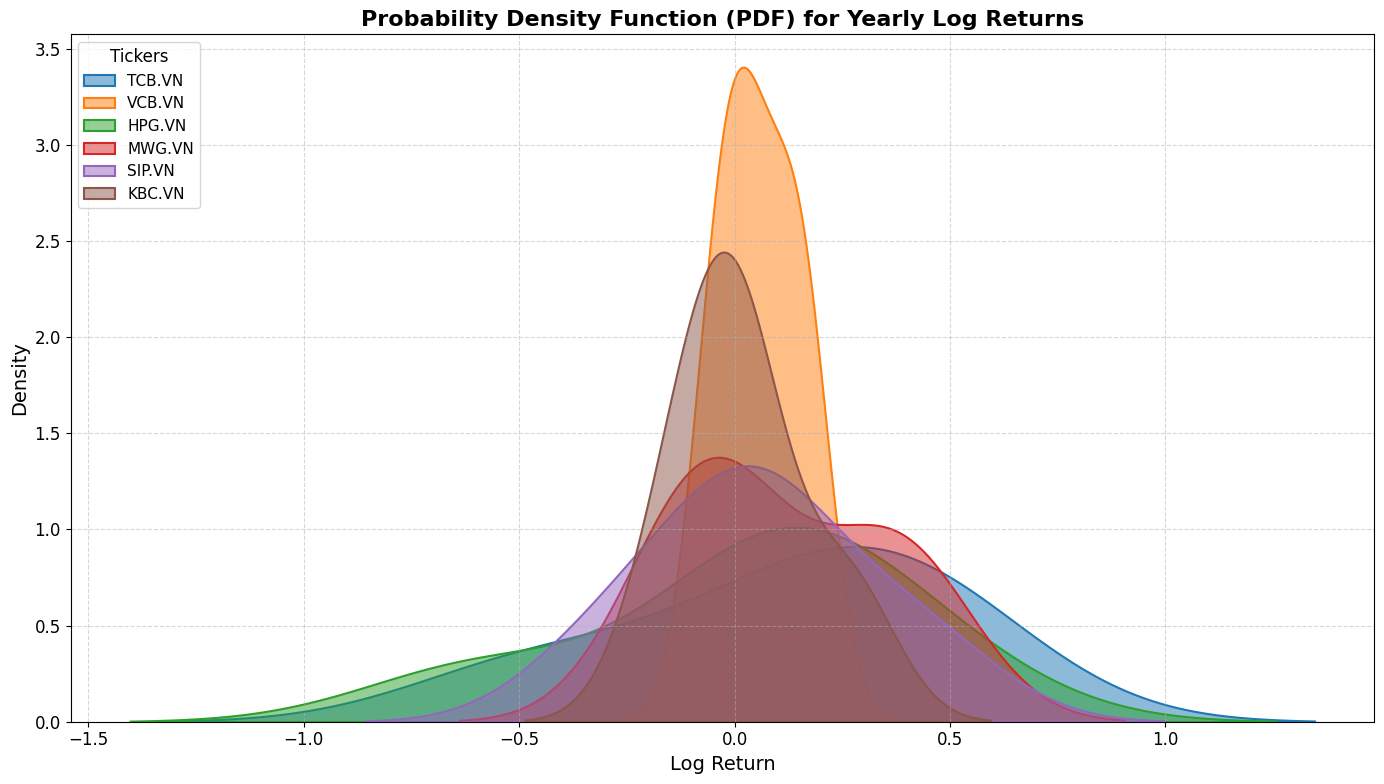

In [ ]:
# PROBABILITY DENSITY FUNCTION FOR EACH STOCK
plt.figure(figsize=(14, 8))
import seaborn as sns
colors = sns.color_palette('tab10', len(yearly_log_returns.columns))
for i, col in enumerate(yearly_log_returns.columns):
    sns.kdeplot(
        yearly_log_returns[col], label=col,
        fill=True, alpha=0.5, color=colors[i], linewidth=1.5
    )
plt.title('Probability Density Function (PDF) for Yearly Log Returns',
          fontsize=16, fontweight='bold')
plt.xlabel('Log Return', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Tickers', fontsize=11, loc='upper left')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# BUILD PDF DICT
pdf_dict = {}
for column in yearly_log_returns.columns:
    kde = gaussian_kde(yearly_log_returns[column])
    min_return   = yearly_log_returns[column].min()
    max_return   = yearly_log_returns[column].max()
    return_range = np.linspace(min_return, max_return, 1000)
    pdf_values   = kde(return_range)
    pdf_dict[column] = {'returns': return_range, 'pdf': pdf_values}


In [ ]:
# MONTE CARLO SIMULATION
num_samples = 10000

samples = np.random.multivariate_normal(
    yearly_log_returns.mean().values,
    vcv_matrix.values,
    size=num_samples
)

transformed_samples = np.zeros_like(samples)
for i, column in enumerate(yearly_log_returns.columns):
    returns   = pdf_dict[column]['returns']
    pdf       = pdf_dict[column]['pdf']
    cdf       = np.cumsum(pdf) * np.diff(returns)[0]
    for j in range(num_samples):
        sv         = samples[j, i]
        percentile = np.interp(sv, returns, cdf)
        transformed_samples[j, i] = np.interp(percentile, cdf, returns)

simulation = pd.DataFrame(transformed_samples, columns=yearly_log_returns.columns)
simulation


Ticker,TCB.VN,VCB.VN,HPG.VN,MWG.VN,SIP.VN,KBC.VN
0,-0.086198,0.112166,0.257771,-0.118563,-0.223426,0.262081
1,0.140282,-0.051871,0.203798,-0.118563,0.051403,-0.099127
2,0.028520,-0.051871,0.018616,0.019907,-0.289058,0.114232
3,-0.031431,0.012936,-0.234633,-0.118563,0.305816,-0.082603
4,0.276918,-0.051871,0.207523,-0.118563,0.196294,0.142879
...,...,...,...,...,...,...
9995,-0.207197,0.170105,0.082566,0.385284,-0.225414,-0.059440
9996,-0.212415,-0.051871,-0.387767,-0.118563,0.140551,-0.034104
9997,0.500719,0.141621,0.085756,0.385284,-0.092222,0.262081
9998,0.041598,0.170105,0.005362,-0.052182,-0.117506,-0.063635


In [ ]:
# BEGINNING VALUE PER STOCK
initial_value    = INITIAL_CAPITAL * EQUITY_WEIGHT
beginning_value  = OrderedDict(
    (key, value * initial_value) for key, value in weights.items()
    if key in simulation.columns
)
beginning_value_series = pd.Series(beginning_value)
print("Beginning value per stock:")
print(beginning_value_series.apply(lambda x: f'${x:,.0f}'))


Beginning value per stock:
TCB.VN    $1,790,550,000
VCB.VN    $1,213,650,000
HPG.VN    $1,899,180,000
MWG.VN    $1,326,510,000
SIP.VN    $1,295,370,000
KBC.VN    $1,474,650,000
dtype: object


In [ ]:
# ENDING PORTFOLIO VALUE
sim_aligned   = simulation[list(beginning_value.keys())]
ending_value  = (beginning_value_series * (1 + sim_aligned)).sum(axis=1)
ending_value


,0
0,9.411036e+09
1,9.338322e+09
2,8.843802e+09
3,8.630781e+09
4,1.013461e+10
...,...
9995,9.123602e+09
9996,7.794678e+09
9997,1.100932e+10
9998,8.975752e+09


In [ ]:
# VALUE AT RISK
def calculate_var(ending_value, alpha=0.05):
    ranked = ending_value.rank(pct=True)
    return ending_value[ranked <= alpha].max()

VaR_95_value = calculate_var(ending_value, 0.05)
VaR_99_value = calculate_var(ending_value, 0.01)

print(f"VaR at 95% confidence level (5th percentile) : ${VaR_95_value:,.2f}")
print(f"VaR at 99% confidence level (1st percentile) : ${VaR_99_value:,.2f}")


VaR at 95% confidence level (5th percentile) : $7,979,337,660.37
VaR at 99% confidence level (1st percentile) : $7,395,800,701.35


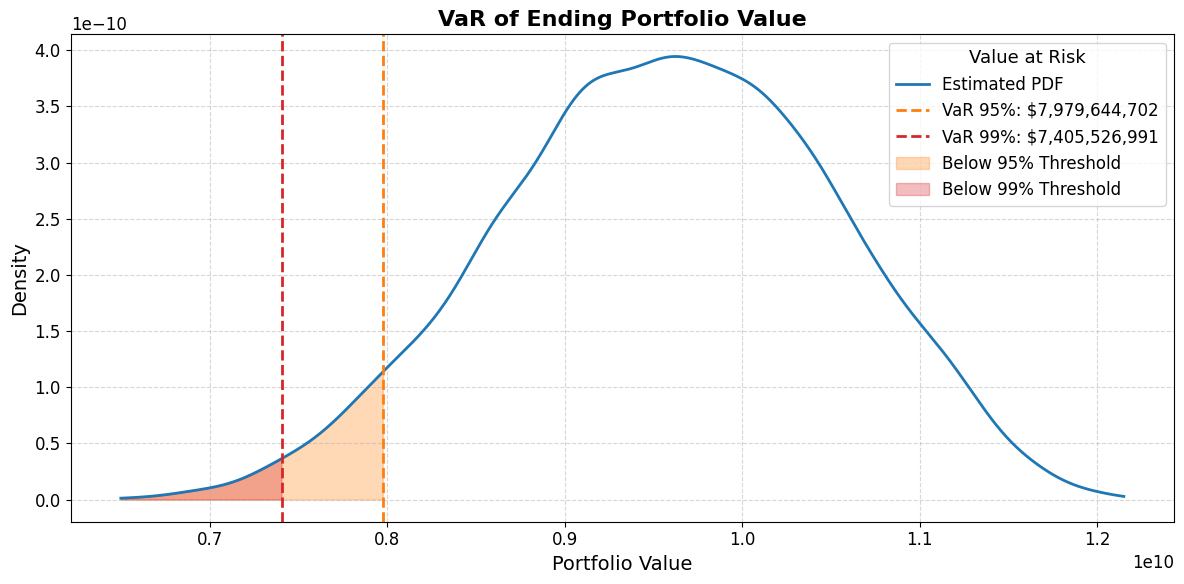

In [ ]:
# VAR DISTRIBUTION PLOT
from scipy.stats import gaussian_kde as gkde
sorted_vals = ending_value.sort_values()
kde_var     = stats.gaussian_kde(sorted_vals)
x_var       = np.linspace(sorted_vals.min(), sorted_vals.max(), 1000)
pdf_vals    = kde_var(x_var)

VaR_95_thr = sorted_vals.quantile(0.05)
VaR_99_thr = sorted_vals.quantile(0.01)

plt.figure(figsize=(12, 6))
plt.plot(x_var, pdf_vals, label='Estimated PDF', color='#1f77b4', linewidth=2)
plt.axvline(VaR_95_thr, color='#ff7f0e', linestyle='--', linewidth=2,
            label=f'VaR 95%: ${VaR_95_thr:,.0f}')
plt.axvline(VaR_99_thr, color='#d62728', linestyle='--', linewidth=2,
            label=f'VaR 99%: ${VaR_99_thr:,.0f}')
plt.fill_between(x_var, pdf_vals, 0, where=(x_var <= VaR_95_thr),
                 color='#ff7f0e', alpha=0.3, label='Below 95% Threshold')
plt.fill_between(x_var, pdf_vals, 0, where=(x_var <= VaR_99_thr),
                 color='#d62728', alpha=0.3, label='Below 99% Threshold')
plt.title('VaR of Ending Portfolio Value', fontsize=16, fontweight='bold')
plt.xlabel('Portfolio Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(fontsize=12, title='Value at Risk', title_fontsize=13)
plt.tight_layout()
plt.show()


# **Section 3: Scenario Analysis**

## **Scenario**

In [ ]:
SCENARIOS = {
    'Bull': {
        'prob'        : 0.25,
        'color'       : '#27AE60',
        'description' : 'GDP ≥7.5%; FTSE EM upgrade Sep/2026; record FDI; public investment breakthrough; well-controlled CPI',
        # Macro factor shifts vs baseline
        'macro': {
            'gdp_growth'      : 0.075,   # GDP Q1/2026 đạt 7.83% → bull duy trì đà tăng
            'cpi_avg'         : 0.045,   # Dầu hạ nhiệt, Hormuz tái mở → CPI đạt target 4.5%
            'policy_rate'     : 0.045,   # NHNN giữ nguyên 4.5% (UOB forecast cả 2026)
            'usdvnd_deprec'   : 0.020,   # Tỷ giá dao động nhẹ ~1%, VND được hỗ trợ bởi FDI
            'fdi_inflow_bn'   : 0.06    # FDI giải ngân 2024 = 27,62 * 1.08
        }
    },
    'Base': {
        'prob'        : 0.50,
        'color'       : '#2980B9',
        'description' : 'GDP ~7.8%; average CPI 4.8%; Brent USD 85–95; exchange rate +2–3%; SBV maintains interest rate at 4.5%',
        'macro': {
            'gdp_growth'      : 0.07,   # Thực tế Q1 7.83%; WB dự báo 6.3% → base ~7%
            'cpi_avg'         : 0.05,   # KBSV baseline: Brent 85–95 USD → CPI 4.8%
            'policy_rate'     : 0.045,   # NHNN không gian nới lỏng bị CPI thu hẹp → giữ nguyên
            'usdvnd_deprec'   : 0.03,   # UOB: USD/VND ~26,300; biên độ NHNN +2–3%
            'fdi_inflow_bn'   : 0.04    # FDI giải ngân 2024 = 27,62 * 1.05
        }
    },
    'Bear': {
        'prob'        : 0.20,
        'color'       : '#E67E22',
        'description' : 'GDP <7%; Brent USD 100 → CPI 5.4%; SBV raises interest rates; VND depreciates; FDI slows down',
        'macro': {
            'gdp_growth'      : 0.063,   # WB downside VN 2026: 6.3%; địa chính trị kéo dài
            'cpi_avg'         : 0.056,   # KBSV bear case: Brent 100 USD → CPI 5.4%
            'policy_rate'     : 0.055,   # CPI vượt target → NHNN tăng 50bps lên 5.0%
            'usdvnd_deprec'   : 0.07,   # VND áp sát biên dưới NHNN ~26,600
            'fdi_inflow_bn'   : -0.05    # Nhà đầu tư ngoại bán ròng; FDI giải ngân chậm
        }
    },
    'Stress': {
        'prob'        : 0.05,
        'color'       : '#C0392B',
        'description' : 'Hormuz prolonged closure; Brent >110 USD; CPI >6%; foreign capital flight; sharp VND depreciation',
        'macro': {
            'gdp_growth'      : 0.03,   # Cú sốc cung cầu kép: năng lượng + chuỗi cung ứng
            'cpi_avg'         : 0.065,   # Giá năng lượng + logistics bùng nổ → CPI 6%+
            'policy_rate'     : 0.065,  # NHNN thắt chặt khẩn cấp kiềm chế lạm phát + bảo vệ VND
            'usdvnd_deprec'   : 0.10,   # Tháo chạy tài sản an toàn; VND mất giá >5%
            'fdi_inflow_bn'   : -0.15    # FDI đình trệ; giải ngân giảm mạnh do bất ổn toàn cầu lấy 2025 giảm 5%
        }
    }
}

TRADING_DAYS = 252
VN_RF        = risk_free_rate

print(f"{'Scenario':<10} {'Prob':>6} {'GDP':>6} {'CPI':>6} {'Rate':>6} {'VND depr':>9} {'FDI(bn)':>8}")
print("—" * 70)
for name, cfg in SCENARIOS.items():
    m = cfg['macro']
    print(f" {name:<10} {cfg['prob']:>6.0%} {m['gdp_growth']:>6.1%} {m['cpi_avg']:>6.1%} "
          f"{m['policy_rate']:>6.2%} {m['usdvnd_deprec']:>9.1%} {m['fdi_inflow_bn']:>8.1%}")

# VNI BENCHMARK CALIBRATION
ERP_EXPANSION = {
    'Bull'  : -0.010,   # Risk-on: ERP nén lại (-1pp)
    'Base'  :  0.000,   # Baseline: ERP giữ nguyên
    'Bear'  :  0.020,   # Risk-off nhẹ: ERP mở rộng +2pp
    'Stress':  0.050,   # Risk-off mạnh / capital flight: ERP +5pp
}

EQUITY_DURATION = 12


Scenario     Prob    GDP    CPI   Rate  VND depr  FDI(bn)
——————————————————————————————————————————————————————————————————————
 Bull          25%   7.5%   4.5%  4.50%      2.0%     6.0%
 Base          50%   7.0%   5.0%  4.50%      3.0%     4.0%
 Bear          20%   6.3%   5.6%  5.50%      7.0%    -5.0%
 Stress         5%   3.0%   6.5%  6.50%     10.0%   -15.0%


In [ ]:
# STOCK PROJECTED RETURNS
STOCK_SENSITIVITIES_RAW = {
    # ── Financials ─────────────────────────────────────────
    # NIM nở ra khi IR tăng (ngắn hạn dương), nhưng chất lượng tài sản xấu đi
    # CPI cao → thắt chặt → tăng trưởng tín dụng chậm → GDP yếu → nợ xấu tăng
    'TCB.VN': dict(gdp=+2.5, cpi=-1.0, ir=+1.0, fx=-0.5, fdi=+1.0),
    'VCB.VN': dict(gdp=+2.0, cpi=-1.5, ir=+0.5, fx=+1.0, fdi=+1.5),

    # ── Materials ─────────────────────────────────────────
    # Thép phụ thuộc GDP công nghiệp + FDI giải ngân (nhà máy, hạ tầng)
    # CPI → chi phí đầu vào tăng; IR cao → bất động sản chậm → cầu thép giảm
    'HPG.VN': dict(gdp=+3.0, cpi=-2.0, ir=-1.5, fx=-1.0, fdi=+2.5),

    # ── Bán lẻ (Retail) ──────────────────────────────────────
    # GDP cao → sức mua tiâu dùng tăng → doanh thu bán lẻ bứt phá
    # CPI cao → chi phí sinh hoạt tăng → ngườĺ dân thắt chặt chi tiâu tự chọn
    # IR cao → tín dụng tiêu dùng đắt hơn → doanh số hàng trả góp (điện thoại, điện máy) giảm
    # FX depreciation → giá hàng nhập khẩu tăng → biên lợi nhuận bị ép (FRT nhập Apple, Samsung)
    # FDI cao → tầng lớœchuyân gia/công nhân nưỜ ngoài → nhu cầu tiâu dùng tăng nhẹ
    'MWG.VN': dict(gdp=+2.5, cpi=-2.5, ir=-1.5, fx=-1.5, fdi=+0.5),

    # ── Bất động sản (Real Estate) ──────────────────
    # GDP cao → niềm tin thị trường + thu nhập tăng → nhu cầu nhà ở / KCN tăng
    # CPI cao → chi phí xây dựng leo thang → biân lợi nhuận dự án bị bào mòn
    # IR cao → lãi vay mua nhà & vay phát triển dự án tăng → thanh khoản thị trường chậm
    # FX: tác động trung tính vỗi SIP (chủ yếu thị trường nội địế); KBC hưởng lợi từ FDI giải ngân
    # FDI cao → nhu cầu thuê/mua KCN tăng mạnh (đặc biệt KBC – chủ đầu tư KCN)
    'SIP.VN': dict(gdp=+2.5, cpi=-2.0, ir=-3.0, fx= 0.0, fdi=+1.5),
    'KBC.VN': dict(gdp=+3.0, cpi=-1.0, ir=-2.5, fx=+0.5, fdi=+3.0)
}

# BASE CASE MACRO
base_macro = SCENARIOS['Base']['macro']

# PROJECTED ANNUAL RETURN
bl_posterior_total_returns = {}
for t in STOCK_SENSITIVITIES_RAW:
    raw_t = t
    excess = ret_bl.get(raw_t, np.nan)
    if np.isnan(excess):
        if raw_t in log_returns.columns:
            excess = log_returns[raw_t].mean() * TRADING_DAYS - VN_RF
        else:
            excess = 0.0
    bl_posterior_total_returns[t] = excess + VN_RF

projected_returns = {}

# First, calculate for the 'Base' scenario
proj_base = {}
for ticker in STOCK_SENSITIVITIES_RAW:
    proj_base[ticker] = viewdict.get(ticker, 0.0) + VN_RF
projected_returns['Base'] = proj_base

# Then, calculate for other scenarios
for scen_name, cfg in SCENARIOS.items():
    if scen_name == 'Base':
        continue

    scen_macro = cfg['macro']
    proj = {}
    for ticker, sens in STOCK_SENSITIVITIES_RAW.items():
        delta_gdp  = scen_macro['gdp_growth']    - base_macro['gdp_growth']
        delta_cpi  = scen_macro['cpi_avg']         - base_macro['cpi_avg']
        delta_ir   = scen_macro['policy_rate']   - base_macro['policy_rate']
        delta_fx   = scen_macro['usdvnd_deprec'] - base_macro['usdvnd_deprec']
        delta_fdi  = scen_macro['fdi_inflow_bn']   - base_macro['fdi_inflow_bn']

        # Adjustment = (GDP Sensitivity * Delta GDP) + (CPI Sensitivity * Delta CPI) + (Interest Rate Sensitivity * Delta IR) + (FX Sensitivity * Delta FX) + (FDI Sensitivity * Delta FDI)
        adjustment = (
            sens['gdp']    * delta_gdp    +
            sens['cpi']    * delta_cpi    +
            sens['ir']     * delta_ir     +
            sens['fx']     * delta_fx     +
            sens['fdi']    * delta_fdi
        )
        proj[ticker] = projected_returns['Base'][ticker] + adjustment
    projected_returns[scen_name] = proj

# PROJECTED RETURNS TABLE
from IPython.display import display as ipy_display
import pandas as pd

rows_pr = []
for ticker in STOCK_SENSITIVITIES_RAW:
    row = {'Ticker': ticker,
           'Sector': {v: k for k, vals in tickers_dict.items() for v in vals}.get(ticker, '?'),
           'BL Base Return': f"{bl_posterior_total_returns[ticker]:.2%}"} # Display BL posterior as a reference
    for scen in SCENARIOS:
        row[scen] = f"{projected_returns[scen][ticker]:.2%}"
    rows_pr.append(row)

pr_df = pd.DataFrame(rows_pr).set_index('Ticker')
print("Projected Annual Returns by Stock × Scenario  (as of 30/04/2026)")
print("—" * 75)
ipy_display(pr_df)

MGMT_START_STR = '2026-05-01'

Projected Annual Returns by Stock × Scenario  (as of 30/04/2026)
———————————————————————————————————————————————————————————————————————————


,Sector,BL Base Return,Bull,Base,Bear,Stress
Ticker,,,,,,
TCB.VN,Financials,4.63%,23.75%,19.50%,7.15%,-12.50%
VCB.VN,Financials,4.50%,33.37%,29.62%,18.32%,-1.13%
HPG.VN,Materials,4.65%,32.59%,24.09%,-7.21%,-48.41%
MWG.VN,Consumer Discretionary,4.52%,23.92%,18.92%,3.67%,-17.83%
SIP.VN,Real Estate,4.52%,15.49%,10.24%,-9.21%,-37.26%
KBC.VN,Real Estate,4.56%,23.80%,16.30%,-13.90%,-55.70%


In [ ]:
# INITIAL PORTFOLIO
import yfinance as yf
entry_date_str = '2026-05-04'
entry_prices_raw = yf.download(equity_tickers, start=entry_date_str, end='2026-05-05', auto_adjust=True, progress=False)

if isinstance(entry_prices_raw.columns, pd.MultiIndex):
    entry_prices = entry_prices_raw['Close'].loc[entry_date_str]
elif isinstance(entry_prices_raw, pd.DataFrame):
    entry_prices = entry_prices_raw['Close'].loc[entry_date_str]
else:
    entry_prices = entry_prices_raw.loc[entry_date_str]

last_prices = entry_prices
target_equity_capital = INITIAL_CAPITAL * EQUITY_WEIGHT
initial_cash_reserve  = INITIAL_CAPITAL * CASH_WEIGHT

TRADING_DAYS_Y = TRADING_DAYS

holdings       = {}
weights_target = {}

# Define ws_proj here as it is used immediately after
available_tickers = [t for t in weights if t in STOCK_SENSITIVITIES_RAW]
ws_proj = {t: weights[t] for t, w in weights.items() if t in available_tickers}
total_w = sum(ws_proj.values())
ws_proj = {t: w / total_w for t, w in ws_proj.items()}

for ticker, w in ws_proj.items():
    price = last_prices.get(ticker, np.nan)
    if np.isnan(price) or price <= 0:
        continue
    alloc  = target_equity_capital * w
    shares = int(alloc // price)
    holdings[ticker]       = shares
    weights_target[ticker] = w

invested  = sum(holdings[t] * last_prices[t] for t in holdings)

# Use SALES_CHARGE_BUY for the entry fee
entry_fee = invested * SALES_CHARGE_BUY

uninvested_equity_portion = target_equity_capital - invested
remaining_cash = initial_cash_reserve + uninvested_equity_portion - entry_fee

print(f"Initial Portfolio (Entry Date: {entry_date_str})")
print("—" * 50)
print(f"Total Capital:           {INITIAL_CAPITAL:,.0f} VND")
print(f"Equity Invested:         {invested:,.0f} VND")
print(f"Entry Fee ({SALES_CHARGE_BUY*100:.2f}%):        {entry_fee:,.0f} VND")
print(f"Remaining Cash Reserve:  {remaining_cash:,.0f} VND")
print("Initial Holdings:")
print(f"  {'Ticker':<8} {'Shares':<10} {'Price':<12} {'Value':<15} {'Weight':<10}")
print(f"  {'—'*8:<8} {'—'*10:<10} {'—'*12:<12} {'—'*15:<15} {'—'*10:<10}")

for ticker, num_shares in holdings.items():
    price = last_prices[ticker]
    value = num_shares * price
    weight = value / invested
    print(f"  {ticker:<8} {num_shares:<10} {price:,.0f} VND {value:,.0f} VND {weight:.2%}")
print(f"  {'Total':<8} {'':<10} {'':<12} {invested:,.0f} VND {sum(holdings[t]*last_prices[t]/invested for t in holdings):.2%}")

print("")

Initial Portfolio (Entry Date: 2026-05-04)
——————————————————————————————————————————————————
Total Capital:           10,000,000,000 VND
Equity Invested:         8,999,844,261 VND
Entry Fee (0.15%):        13,499,766 VND
Remaining Cash Reserve:  986,655,972 VND
Initial Holdings:
  Ticker   Shares     Price        Value           Weight    
  ———————— —————————— ———————————— ——————————————— ——————————
  TCB.VN   53370      33,550 VND 1,790,563,500 VND 19.90%
  VCB.VN   19994      60,700 VND 1,213,635,800 VND 13.49%
  HPG.VN   70069      27,104 VND 1,899,184,389 VND 21.10%
  MWG.VN   15624      84,900 VND 1,326,477,600 VND 14.74%
  SIP.VN   22930      56,492 VND 1,295,350,722 VND 14.39%
  KBC.VN   42805      34,450 VND 1,474,632,250 VND 16.39%
  Total                            8,999,844,261 VND 100.00%



In [ ]:
# REBALANCING TABLE (Base Case)
np.random.seed(0)
base_ticker_order = list(ws_proj.keys())
base_proj_daily   = np.array([projected_returns['Base'][t] for t in base_ticker_order]) / TRADING_DAYS
base_cov_daily    = cov_matrix.loc[base_ticker_order, base_ticker_order].values / TRADING_DAYS

monthly_days      = [21] * 12
cumulative_days   = np.cumsum([0] + monthly_days)

sim_stock_path = np.ones((sum(monthly_days) + 1, len(base_ticker_order)))
daily_shocks_rb = np.random.multivariate_normal(base_proj_daily, base_cov_daily,
                                                 size=sum(monthly_days))
for d in range(sum(monthly_days)):
    sim_stock_path[d+1] = sim_stock_path[d] * (1 + daily_shocks_rb[d])

months_list = pd.date_range('2026-05-31', periods=12, freq='ME')
rebalance_records  = []
current_weights_rb = dict(ws_proj)

for m_idx, end_day_idx in enumerate(cumulative_days[1:]):
    prices_eom = {t: last_prices[t] * sim_stock_path[end_day_idx, i]
                  for i, t in enumerate(base_ticker_order)}

    total_val = sum(
        holdings.get(t, 0) * prices_eom[t] for t in base_ticker_order
    ) + remaining_cash

    if total_val <= 0:
        continue

    actual_w = {t: holdings.get(t, 0) * prices_eom[t] / total_val for t in base_ticker_order}
    drift    = {t: abs(actual_w[t] - ws_proj[t]) for t in base_ticker_order}

    if max(drift.values()) < REBALANCE_THRESHOLD:
        continue

    eq_cap_rb = total_val * EQUITY_WEIGHT
    for t in base_ticker_order:
        p       = prices_eom[t]
        cur_sh  = holdings.get(t, 0)
        tgt_sh  = int(eq_cap_rb * ws_proj[t] / p)
        diff_sh = tgt_sh - cur_sh
        if diff_sh == 0:
            continue

        w_before = actual_w[t]
        w_after  = tgt_sh * p / eq_cap_rb

        rebalance_records.append({
            'Date'                     : months_list[m_idx].strftime('%Y-%m-%d'),
            'Stock'                    : t,
            'Weight Before Rebalancing': f'{w_before:.2%}',
            'Buy / Sell'               : 'Buy' if diff_sh > 0 else 'Sell',
            'No. of Stocks'            : abs(diff_sh),
            'Weight After Rebalancing' : f'{w_after:.2%}',
        })
        holdings[t] = tgt_sh

rebalance_df = pd.DataFrame(rebalance_records)
print("Portfolio Rebalancing Events (Management Period: 01/05/2026 – 01/05/2027)")
print(f"Rebalance threshold: ±{REBALANCE_THRESHOLD:.0%}  |  Simulation: Base scenario price path")
print("─" * 75)
if rebalance_df.empty:
    print("  → Không có sự kiện tái cân bằng nào (drift < ±5% trên toàn bộ kỳ quản lý).")
else:
    ipy_display(rebalance_df)


Portfolio Rebalancing Events (Management Period: 01/05/2026 – 01/05/2027)
Rebalance threshold: ±5%  |  Simulation: Base scenario price path
───────────────────────────────────────────────────────────────────────────
  → Không có sự kiện tái cân bằng nào (drift < ±5% trên toàn bộ kỳ quản lý).


## **Risk Management Rules**

In [ ]:
# POSITION-LEVEL RISK ENGINE
# Rule 1: Stop-Loss nhẹ  — giảm 7%  từ giá mua → Bán 50%
# Rule 2: Stop-Loss nặng — giảm 10% từ giá mua → Bán 100%

def apply_position_risk_rules(ticker, entry_price, target_price,
                               current_price, peak_price, shares_held):
    """Kiểm tra risk management rules cho từng vị thế."""
    result = dict(ticker=ticker, entry_price=entry_price,
                  current_price=current_price, peak_price=peak_price,
                  shares_held=shares_held, action='hold',
                  reason=None, shares_to_sell=0, rule_triggered=None)

    pnl_pct      = (current_price - entry_price) / entry_price

    # Rule 2 (ưu tiên cao nhất): Stop-Loss nặng
    if pnl_pct <= -STOP_LOSS_HEAVY:
        result.update(action='sell_all', shares_to_sell=shares_held,
                      rule_triggered='STOP_LOSS_HEAVY',
                      reason=f'Lỗ {pnl_pct:.2%} >= -{STOP_LOSS_HEAVY*100:.0f}% → Bán TOÀN BỘ 100%')
    # Rule 1: Stop-Loss nhẹ
    elif pnl_pct <= -STOP_LOSS_LIGHT:
        result.update(action='sell_half', shares_to_sell=shares_held // 2,
                      rule_triggered='STOP_LOSS_LIGHT',
                      reason=f'Lỗ {pnl_pct:.2%} >= -{STOP_LOSS_LIGHT*100:.0f}% → Bán 50%')
    return result


def simulate_position_risk(ticker, entry_price, target_price, sim_prices):
    """Mô phỏng risk rules trên chuỗi giá hàng ngày."""
    shares = 1000
    peak   = entry_price
    log    = []
    for day, price in enumerate(sim_prices):
        peak = max(peak, price)
        chk  = apply_position_risk_rules(ticker, entry_price, target_price,
                                          price, peak, shares)
        if chk['action'] != 'hold':
            log.append({'Day': day+1, 'Ticker': ticker,
                        'Entry': f'{entry_price:,.0f}',
                        'Current': f'{price:,.0f}', 'Peak': f'{peak:,.0f}',
                        'P&L %': f'{(price-entry_price)/entry_price:.2%}',
                        'Rule': chk['rule_triggered'],
                        'Action': chk['action'].upper(),
                        'Shares Sold': chk['shares_to_sell'],
                        'Reason': chk['reason']})
            shares -= chk['shares_to_sell']
            if shares <= 0:
                break
    return pd.DataFrame(log)


# Demo: Ngưỡng giá trigger cho từng mã (tại ngày vào 04/05/2026)
_bl_h = BlackLittermanHelper()
_tp   = _bl_h.get_target_prices()

print('Position-Level Risk Thresholds (tại ngày vào lệnh 04/05/2026)')
print('=' * 95)
print(f'{"Ticker":<10} {"Entry":>12} {"Target":>12} '
      f'{"SL -7% (sell 50%)":>20} {"SL -10% (sell 100%)":>22}')
print('-' * 95)
for t in holdings:
    ep = last_prices.get(t, float('nan'))
    tp_val = _tp.get(t, float('nan'))
    if ep != ep:
        continue
    print(f'{t:<10} {ep:>12,.0f} {tp_val:>12,.0f} '
          f'{ep*(1-STOP_LOSS_LIGHT):>20,.0f} '
          f'{ep*(1-STOP_LOSS_HEAVY):>22,.0f}')
print('-' * 95)
print('Đơn vị: VND/cổ phiếu')

Position-Level Risk Thresholds (tại ngày vào lệnh 04/05/2026)
Ticker            Entry       Target    SL -7% (sell 50%)    SL -10% (sell 100%)
-----------------------------------------------------------------------------------------------
TCB.VN           33,550       39,029               31,201                 30,195
VCB.VN           60,700       75,000               56,451                 54,630
HPG.VN           27,104       32,670               25,207                 24,394
MWG.VN           84,900       96,362               78,957                 76,410
SIP.VN           56,492       60,000               52,537                 50,842
KBC.VN           34,450       38,000               32,038                 31,005
-----------------------------------------------------------------------------------------------
Đơn vị: VND/cổ phiếu


In [ ]:
# PORTFOLIO-LEVEL RISK ENGINE — NAV Emergency Protocol
# Rule: NAV giảm 10% → Cash >= 70% of equity_initial → Gov Bond 11%/năm

def simulate_nav_emergency(scenario_name='Stress', n_paths=500, random_seed=42):
    """
    So sánh 2 chiến lược khi NAV giảm 10%:
      (A) CÓ Risk Management: bán equity → cash 70% → Gov Bond
      (B) KHÔNG Risk Management: giữ nguyên (hold through)
    """
    np.random.seed(random_seed)

    equity_initial = INITIAL_CAPITAL * EQUITY_WEIGHT
    nav_trigger    = INITIAL_CAPITAL * (1 - NAV_DRAWDOWN_EMERGENCY)

    ticker_lst = list(ws_proj.keys())
    w_vec_nav  = np.array([ws_proj[t] for t in ticker_lst])
    proj_ann   = np.array([projected_returns[scenario_name][t] for t in ticker_lst])
    mu_d       = proj_ann / TRADING_DAYS
    cov_d      = cov_matrix.loc[ticker_lst, ticker_lst].values

    govbond_daily = (1 + GOVBOND_RATE) ** (1 / TRADING_DAYS) - 1
    mgmt_fee_d    = (1 + ANNUAL_MGMT_FEE) ** (1 / TRADING_DAYS) - 1

    wealth_rm   = np.ones((TRADING_DAYS + 1, n_paths))
    wealth_base = np.ones((TRADING_DAYS + 1, n_paths))
    triggered_day = np.full(n_paths, float('nan'))

    shocks = np.random.multivariate_normal(mu_d, cov_d, size=(TRADING_DAYS, n_paths))
    port_ret = shocks @ w_vec_nav

    for path in range(n_paths):
        nav_rm = nav_hold = float(INITIAL_CAPITAL)
        triggered = False
        cash_bond = cash_res = equity_kept = 0.0

        for d in range(TRADING_DAYS):
            r = port_ret[d, path]

            nav_hold *= (1 + r - mgmt_fee_d)
            wealth_base[d+1, path] = nav_hold / INITIAL_CAPITAL

            if not triggered:
                nav_rm *= (1 + r - mgmt_fee_d)
                wealth_rm[d+1, path] = nav_rm / INITIAL_CAPITAL
                if nav_rm <= nav_trigger:
                    triggered = True
                    triggered_day[path] = d + 1
                    equity_kept = nav_rm * EQUITY_WEIGHT * (1 - EMERGENCY_CASH_TARGET)
                    cash_bond   = nav_rm * EQUITY_WEIGHT * EMERGENCY_CASH_TARGET
                    cash_res    = nav_rm * CASH_WEIGHT
            else:
                equity_kept *= (1 + r - mgmt_fee_d)
                cash_bond   *= (1 + govbond_daily)
                nav_rm = equity_kept + cash_bond + cash_res
                wealth_rm[d+1, path] = nav_rm / INITIAL_CAPITAL

    return wealth_rm, wealth_base, triggered_day

# Stress Scenario
print('Chạy NAV Emergency Protocol simulation — Stress Scenario (1,000 paths)...')
wm_rm, wm_base, trig_days = simulate_nav_emergency('Stress', n_paths=1000)

final_rm   = wm_rm[-1, :]   - 1
final_base = wm_base[-1, :] - 1

n_trig   = int(np.sum(~np.isnan(trig_days)))
pct_trig = n_trig / len(trig_days)
avg_trig = float(np.nanmean(trig_days))

govbond_daily = (1 + GOVBOND_RATE) ** (1 / TRADING_DAYS) - 1

med_rm_p   = np.median(wm_rm,   axis=1)
med_base_p = np.median(wm_base, axis=1)
mdd_rm   = ((med_rm_p   - np.maximum.accumulate(med_rm_p))   / np.maximum.accumulate(med_rm_p)).min()
mdd_base = ((med_base_p - np.maximum.accumulate(med_base_p)) / np.maximum.accumulate(med_base_p)).min()

print(f'{"─"*68}')
print(f'  Tỷ lệ paths kích hoạt RM:   {pct_trig:.1%}  ({n_trig}/1000 paths)')
print(f'  Ngày kích hoạt trung bình:  Day {avg_trig:.0f} / 252')
print(f'  Gov Bond Rate:              {GOVBOND_RATE*100:.1f}%/năm → {govbond_daily*100:.4f}%/ngày')
print(f'{"─"*68}')
print(f'  Kết quả cuối kỳ (median):')
print(f'    CÓ Risk Management:    {np.median(final_rm):>8.2%}')
print(f'    KHÔNG Risk Management: {np.median(final_base):>8.2%}')
print(f'    Lợi ích bảo vệ:        {np.median(final_rm)-np.median(final_base):>+8.2%}')
print(f'  VaR 95% (worst 5%):')
print(f'    CÓ Risk Management:    {np.percentile(final_rm, 5):>8.2%}')
print(f'    KHÔNG Risk Management: {np.percentile(final_base, 5):>8.2%}')
print(f'  Max Drawdown (median path):')
print(f'    CÓ Risk Management:    {mdd_rm:>8.2%}')
print(f'    KHÔNG Risk Management: {mdd_base:>8.2%}')
print(f'    Giảm thiểu tác hại:    {mdd_rm-mdd_base:>+8.2%}')

Chạy NAV Emergency Protocol simulation — Stress Scenario (1,000 paths)...
────────────────────────────────────────────────────────────────────
  Tỷ lệ paths kích hoạt RM:   94.7%  (947/1000 paths)
  Ngày kích hoạt trung bình:  Day 67 / 252
  Gov Bond Rate:              11.0%/năm → 0.0414%/ngày
────────────────────────────────────────────────────────────────────
  Kết quả cuối kỳ (median):
    CÓ Risk Management:     -11.09%
    KHÔNG Risk Management:  -28.34%
    Lợi ích bảo vệ:         +17.24%
  VaR 95% (worst 5%):
    CÓ Risk Management:     -16.40%
    KHÔNG Risk Management:  -50.52%
  Max Drawdown (median path):
    CÓ Risk Management:     -11.16%
    KHÔNG Risk Management:  -28.34%
    Giảm thiểu tác hại:     +17.17%


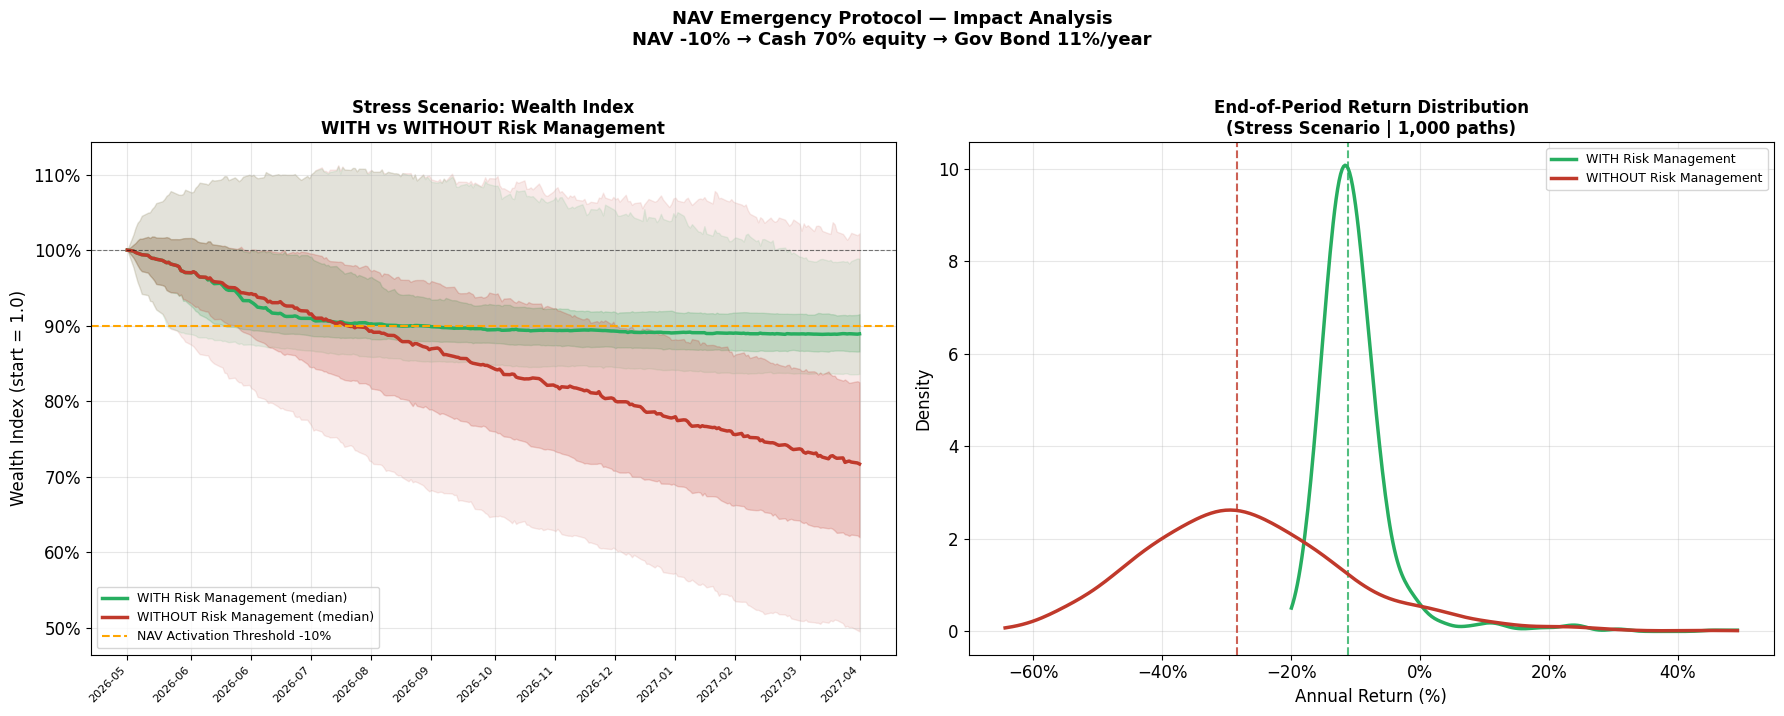

In [ ]:
# STRESS SCENARIO PROTECTION
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import gaussian_kde as gkde_nav

dates_nav = pd.bdate_range(start=MGMT_START_STR, periods=TRADING_DAYS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
color_rm, color_base = '#27AE60', '#C0392B'

for wm, clr, lbl in [(wm_rm, color_rm, 'WITH Risk Management'),
                      (wm_base, color_base, 'WITHOUT Risk Management')]:
    p5  = np.percentile(wm, 5,  axis=1)
    p25 = np.percentile(wm, 25, axis=1)
    p50 = np.percentile(wm, 50, axis=1)
    p75 = np.percentile(wm, 75, axis=1)
    p95 = np.percentile(wm, 95, axis=1)
    ax1.fill_between(dates_nav, p5,  p95, alpha=0.10, color=clr)
    ax1.fill_between(dates_nav, p25, p75, alpha=0.20, color=clr)
    ax1.plot(dates_nav, p50, color=clr, lw=2.5, label=f'{lbl} (median)')

ax1.axhline(1 - NAV_DRAWDOWN_EMERGENCY, color='orange', ls='--', lw=1.5,
            label=f'NAV Activation Threshold -{NAV_DRAWDOWN_EMERGENCY*100:.0f}%')
ax1.axhline(1.0, color='black', ls='--', lw=0.8, alpha=0.5)
ax1.set_title('''Stress Scenario: Wealth Index
WITH vs WITHOUT Risk Management''',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Wealth Index (start = 1.0)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax1.legend(fontsize=9, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(dates_nav[::21])
ax1.set_xticklabels([d.strftime('%Y-%m') for d in dates_nav[::21]],
                     rotation=45, ha='right', fontsize=8)

for ret_arr, clr, lbl in [(final_rm, color_rm, 'WITH Risk Management'),
                            (final_base, color_base, 'WITHOUT Risk Management')]:
    kde_ = gkde_nav(ret_arr)
    x_   = np.linspace(ret_arr.min(), ret_arr.max(), 300)
    ax2.plot(x_*100, kde_(x_), color=clr, lw=2.5, label=lbl)
    ax2.axvline(np.median(ret_arr)*100, color=clr, ls='--', lw=1.5, alpha=0.8)
ax2.set_title('End-of-Period Return Distribution\n(Stress Scenario | 1,000 paths)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Annual Return (%)')
ax2.set_ylabel('Density')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    'NAV Emergency Protocol — Impact Analysis\n'
    f'NAV -10% → Cash {EMERGENCY_CASH_TARGET*100:.0f}% equity → Gov Bond {GOVBOND_RATE*100:.0f}%/year',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Return**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# PORTFOLIO PROJECTED RETURNS
available_tickers = [t for t in weights if t in STOCK_SENSITIVITIES_RAW]
ws_proj = {t: weights[t] for t in available_tickers}
total_w = sum(ws_proj.values())
ws_proj = {t: w / total_w for t, w in ws_proj.items()}

# Calculate port_proj_annual
port_proj_annual = {}
for scen_name in SCENARIOS:
    weighted_returns = 0
    for ticker, weight in ws_proj.items():
        if ticker in projected_returns[scen_name]:
            weighted_returns += weight * projected_returns[scen_name][ticker]
    port_proj_annual[scen_name] = weighted_returns

# PROJECTED DAILY RETURN SIMULATION
np.random.seed(42)
SIM_DAYS   = TRADING_DAYS
N_PATHS    = 5000

ticker_order = list(ws_proj.keys())
w_vec        = np.array([ws_proj[t] for t in ticker_order])

try:
    cov_daily = cov_matrix.loc[ticker_order, ticker_order].values
except Exception:
    hist = log_returns[[t for t in ticker_order if t in log_returns.columns]]
    cov_daily = hist.cov().values

scenario_paths  = {}
scenario_wealth = {}

# Calculate daily management fee rate once
mgmt_fee_daily_rate = (1 + ANNUAL_MGMT_FEE)**(1/TRADING_DAYS) - 1

for scen_name, cfg in SCENARIOS.items():
    proj_ann  = np.array([projected_returns[scen_name][t] for t in ticker_order])
    mu_daily   = proj_ann / TRADING_DAYS

    daily_shocks = np.random.multivariate_normal(mu_daily, cov_daily, size=(SIM_DAYS, N_PATHS))
    # Apply management fee to daily portfolio returns before calculating wealth
    port_daily_paths = (daily_shocks @ w_vec) - mgmt_fee_daily_rate

    wealth = np.ones((SIM_DAYS + 1, N_PATHS))
    for d in range(SIM_DAYS):
        wealth[d+1] = wealth[d] * (1 + port_daily_paths[d])

    scenario_paths[scen_name]  = port_daily_paths
    scenario_wealth[scen_name] = wealth

# SECTOR-LEVEL PROJECTED RETURNS
sector_proj = {}
for scen in SCENARIOS:
    sector_proj[scen] = {}
    for sector, tickers_s in tickers_dict.items():
        tickers_in_ws_proj = [t for t in tickers_s if t in ws_proj]
        if tickers_in_ws_proj:
            sector_proj[scen][sector] = np.mean([projected_returns[scen][t] for t in tickers_in_ws_proj])

print("Portfolio Projected Annual Returns by Scenario:")
print("─" * 50)
for scen, r in port_proj_annual.items():
    std_ann = np.std(scenario_paths[scen].sum(axis=0))  # cross-path std of total return
    print(f"  {scen:<8}: {r:>7.2%}  |  prob={SCENARIOS[scen]['prob']:.0%}  |  {SCENARIOS[scen]['description'][:55]}")

prob_wtd = sum(SCENARIOS[s]['prob'] * port_proj_annual[s] for s in SCENARIOS)
print(f"\n  Probability-weighted expected return: {prob_wtd:.2%}")

Portfolio Projected Annual Returns by Scenario:
──────────────────────────────────────────────────
  Bull    :  25.76%  |  prob=25%  |  GDP ≥7.5%; FTSE EM upgrade Sep/2026; record FDI; public
  Base    :  19.89%  |  prob=50%  |  GDP ~7.8%; average CPI 4.8%; Brent USD 85–95; exchange 
  Bear    :  -0.69%  |  prob=20%  |  GDP <7%; Brent USD 100 → CPI 5.4%; SBV raises interest 
  Stress  : -29.97%  |  prob=5%  |  Hormuz prolonged closure; Brent >110 USD; CPI >6%; fore

  Probability-weighted expected return: 14.75%


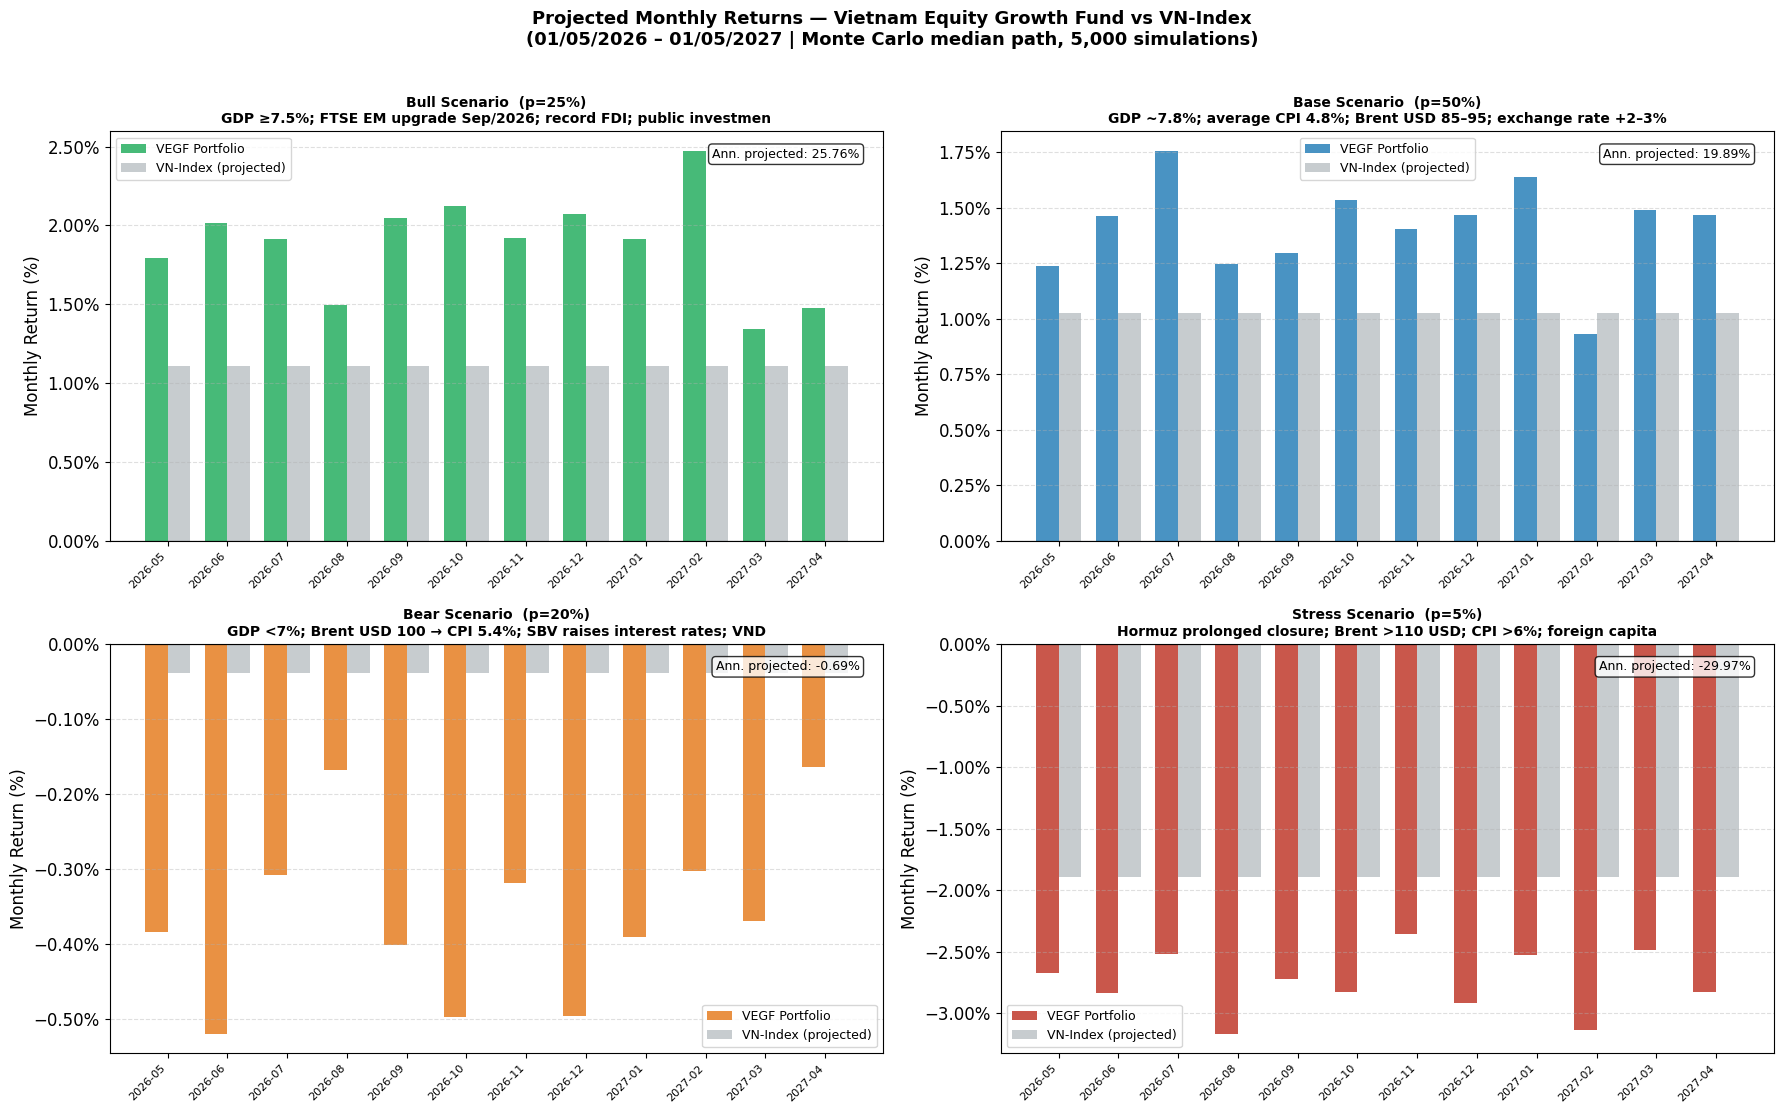

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# MONTHLY RETURNS
MONTHS_LABELS = [f'2026-{m:02d}' for m in range(5, 13)] + \
                [f'2027-{m:02d}' for m in range(1, 5)]

# VN-Index projected monthly return (benchmark) per scenario
# https://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/ctryprem.html
ERP_BASE = 0.0813

def vni_monthly_proj(scen_name):
    base_macro = SCENARIOS['Base']['macro']
    scen_macro = SCENARIOS[scen_name]['macro']

    gdp_adj    = (scen_macro['gdp_growth'] - base_macro['gdp_growth']) * 4
    erp_total  = ERP_BASE + ERP_EXPANSION[scen_name]          # ERP mở rộng khi stress
    delta_rate = scen_macro['policy_rate'] - base_macro['policy_rate']
    rate_hit   = -delta_rate * EQUITY_DURATION                 # P/E compression khi lãi tăng

    ann_vni = VN_RF + erp_total + gdp_adj + rate_hit
    return ann_vni / 12   # monthly

vni_monthly = {s: vni_monthly_proj(s) for s in SCENARIOS}

# Lấy median của N_PATHS = 5,000 paths Monte Carlo làm đại diện cho mỗi scenario.
def get_monthly_rets(wealth_matrix):
    med_path = np.median(wealth_matrix, axis=1)
    monthly_rets = []
    for m in range(12):
        start_day = m * 21
        end_day   = min(start_day + 21, SIM_DAYS)
        r = med_path[end_day] / med_path[start_day] - 1
        monthly_rets.append(r)
    return monthly_rets

monthly_port = {s: get_monthly_rets(scenario_wealth[s]) for s in SCENARIOS}

# CHART: 2×2 Monthly Returns
fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey=False)
axes = axes.flatten()

x = np.arange(12)
w_bar = 0.38

for i, (scen_name, cfg) in enumerate(SCENARIOS.items()):
    ax  = axes[i]
    pm  = monthly_port[scen_name]
    vm  = [vni_monthly[scen_name]] * 12

    bars_p = ax.bar(x - w_bar/2, [r * 100 for r in pm], w_bar,
                    color=cfg['color'], alpha=0.85, label='VEGF Portfolio')
    bars_v = ax.bar(x + w_bar/2, [r * 100 for r in vm], w_bar,
                    color='#BDC3C7', alpha=0.85, label='VN-Index (projected)')

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f"{scen_name} Scenario  (p={cfg['prob']:.0%})\n{cfg['description'][:65]}",
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Monthly Return (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(MONTHS_LABELS, rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ann_r = port_proj_annual[scen_name]
    ax.text(0.97, 0.96, f"Ann. projected: {ann_r:.2%}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Projected Monthly Returns — Vietnam Equity Growth Fund vs VN-Index\n'
             '(01/05/2026 – 01/05/2027 | Monte Carlo median path, 5,000 simulations)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

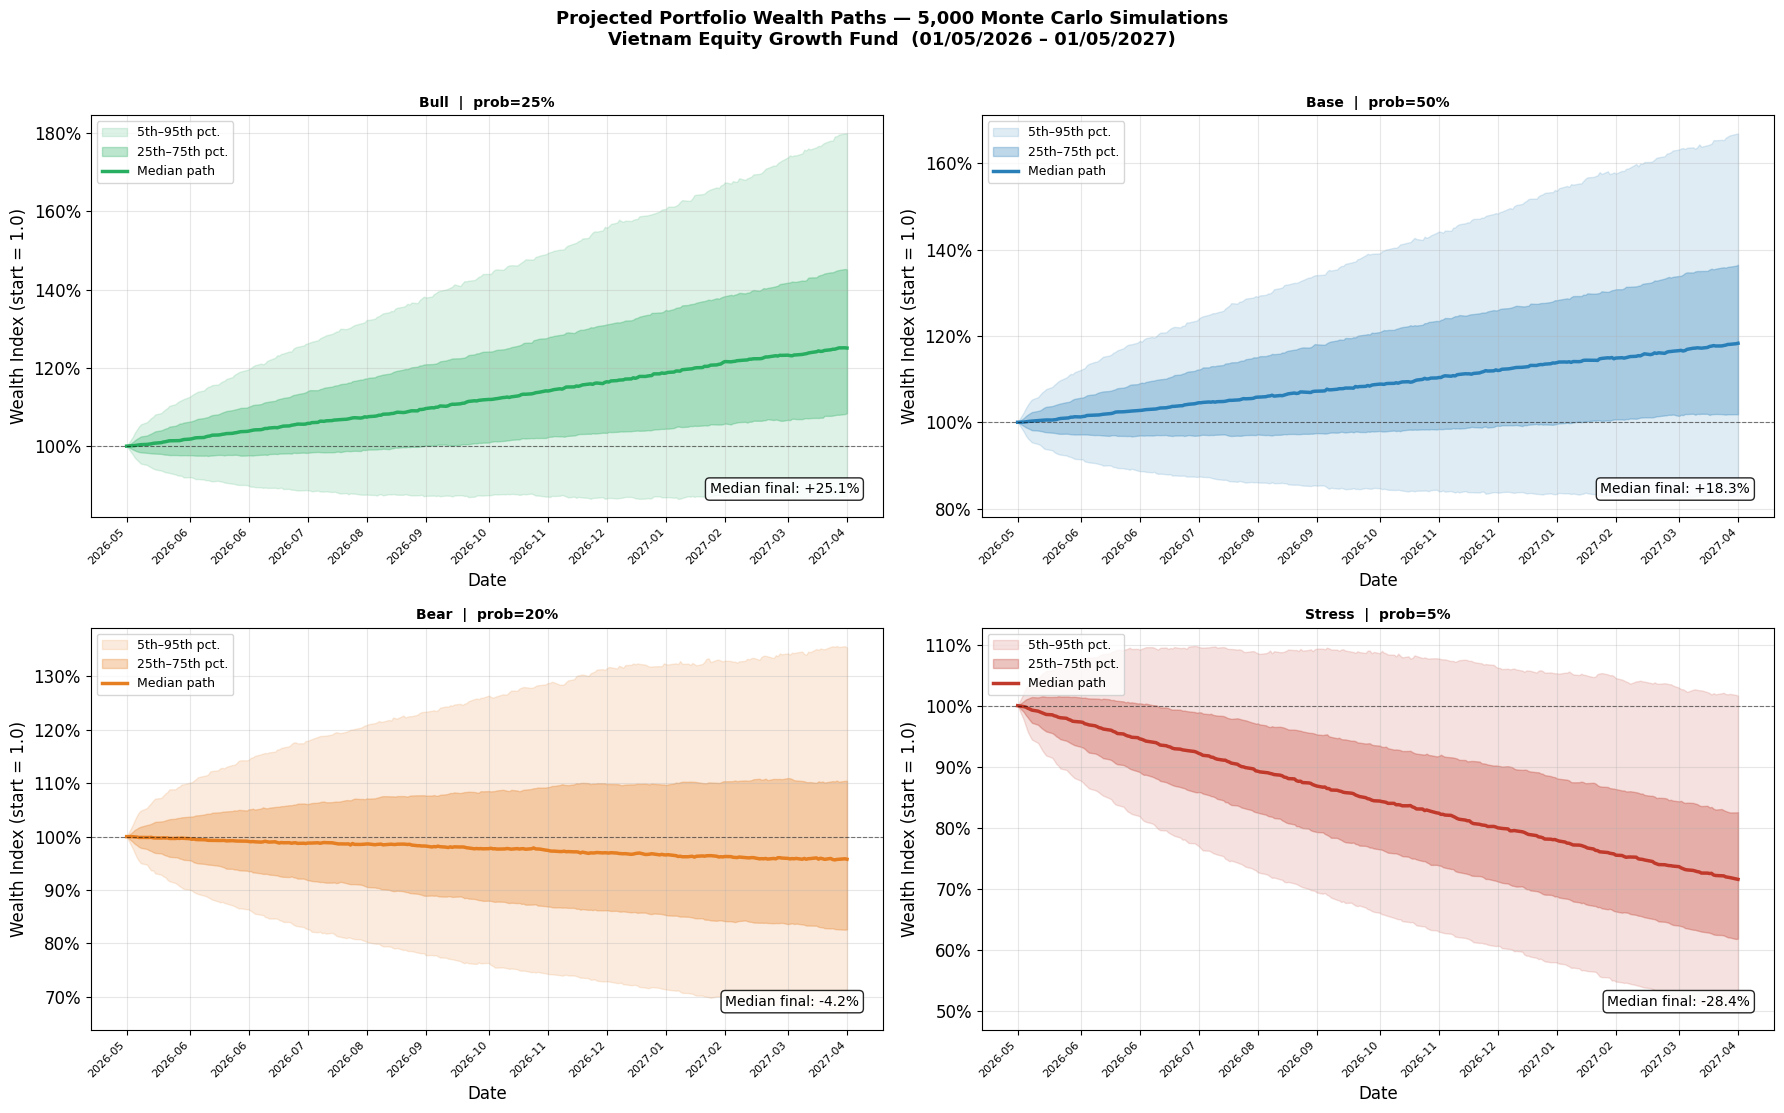

In [ ]:
# WEALTH FANS
import pandas as pd

MGMT_START_STR = '2026-05-01'
dates = pd.bdate_range(start=MGMT_START_STR, periods=SIM_DAYS + 1)

fig, axes_fan = plt.subplots(2, 2, figsize=(18, 11), sharey=False)
axes_fan = axes_fan.flatten()

for i, (scen_name, cfg) in enumerate(SCENARIOS.items()):
    ax = axes_fan[i]
    wealth_m = scenario_wealth[scen_name]

    p5  = np.percentile(wealth_m, 5,  axis=1)
    p25 = np.percentile(wealth_m, 25, axis=1)
    p50 = np.percentile(wealth_m, 50, axis=1)
    p75 = np.percentile(wealth_m, 75, axis=1)
    p95 = np.percentile(wealth_m, 95, axis=1)

    ax.fill_between(dates, p5,  p95, alpha=0.15, color=cfg['color'], label='5th–95th pct.')
    ax.fill_between(dates, p25, p75, alpha=0.30, color=cfg['color'], label='25th–75th pct.')
    ax.plot(dates, p50, color=cfg['color'], lw=2.5, label='Median path')
    ax.axhline(1.0, color='black', ls='--', lw=0.8, alpha=0.5)

    final_p50 = p50[-1]
    ax.text(0.97, 0.06, f"Median final: {(final_p50-1)*100:+.1f}%",
            transform=ax.transAxes, ha='right', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.set_title(f"{scen_name}  |  prob={cfg['prob']:.0%}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Wealth Index (start = 1.0)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(dates[::21])
    ax.set_xticklabels([d.strftime('%Y-%m') for d in dates[::21]], rotation=45, ha='right', fontsize=8)

plt.suptitle('Projected Portfolio Wealth Paths — 5,000 Monte Carlo Simulations\n'
             'Vietnam Equity Growth Fund  (01/05/2026 – 01/05/2027)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# SUMMARY
import numpy as np
import pandas as pd

def get_scenario_series(scen_name):
    """Returns (port_daily, bench_daily, wealth_matrix) as 1D/2D arrays."""
    wealth_m  = scenario_wealth[scen_name]
    med_w     = np.median(wealth_m, axis=1)
    port_d     = np.diff(np.log(np.where(med_w > 0, med_w, 1e-10)))

    np.random.seed(99 + list(SCENARIOS.keys()).index(scen_name))

    _base_macro = SCENARIOS['Base']['macro']
    _scen_macro = SCENARIOS[scen_name]['macro']
    _gdp_adj    = (_scen_macro['gdp_growth'] - _base_macro['gdp_growth']) * 4
    _erp_total  = ERP_BASE + ERP_EXPANSION[scen_name]
    _delta_rate = _scen_macro['policy_rate'] - _base_macro['policy_rate']
    _rate_hit   = -_delta_rate * EQUITY_DURATION
    vni_ann        = VN_RF + _erp_total + _gdp_adj + _rate_hit
    vni_daily_mean = vni_ann / TRADING_DAYS

    vni_noise = np.random.normal(0, 0.008, SIM_DAYS)
    vni_noise = vni_noise - np.mean(vni_noise)

    bench_d   = vni_daily_mean + vni_noise

    return port_d, bench_d, wealth_m


def full_stats(port_d, bench_d, wealth_matrix, rf_ann, label):
    """Compute all performance metrics."""
    rf_d  = rf_ann / TRADING_DAYS


    final_returns_all_paths = wealth_matrix[-1, :] - 1
    ann_r_p  = np.mean(final_returns_all_paths)
    ann_std_p= np.std(final_returns_all_paths)

    ann_r_b  = bench_d.mean() * TRADING_DAYS
    ann_std_b= bench_d.std()  * np.sqrt(TRADING_DAYS)

    exc_p = port_d  - rf_d
    exc_b = bench_d - rf_d
    beta  = np.cov(exc_p, exc_b)[0,1] / np.var(exc_b) if np.var(exc_b) > 0 else 1.0
    alpha_d   = exc_p.mean() - beta * exc_b.mean()
    alpha_ann = alpha_d * TRADING_DAYS

    total_risk   = ann_std_p
    market_risk  = abs(beta) * ann_std_b
    specific_risk= np.sqrt(max(total_risk**2 - market_risk**2, 0))

    sharpe_p = (ann_r_p - rf_ann) / ann_std_p  if ann_std_p > 0 else np.nan
    treynor_p= (ann_r_p - rf_ann) / beta        if beta != 0 else np.nan
    m2       = sharpe_p * ann_std_b + rf_ann     if not np.isnan(sharpe_p) else np.nan
    t2       = treynor_p - (ann_r_b - rf_ann)   if not np.isnan(treynor_p) else np.nan

    active   = port_d - bench_d
    te       = active.std() * np.sqrt(TRADING_DAYS)
    ir       = (active.mean() * TRADING_DAYS) / te if te > 0 else np.nan

    wealth_c = np.cumprod(1 + port_d)
    mdd      = ((wealth_c - np.maximum.accumulate(wealth_c)) / np.maximum.accumulate(wealth_c)).min()

    return dict(label=label, ann_r_p=ann_r_p, ann_std_p=ann_std_p,
                ann_r_b=ann_r_b, ann_std_b=ann_std_b,
                beta=beta, alpha_d=alpha_d, alpha_ann=alpha_ann,
                total_risk=total_risk, market_risk=market_risk, specific_risk=specific_risk,
                sharpe_p=sharpe_p, treynor_p=treynor_p, m2=m2, t2=t2,
                te=te, ir=ir, mdd=mdd, port_d=port_d, bench_d=bench_d)

stats_all = {}
for scen in SCENARIOS:
    p_d, b_d, wm = get_scenario_series(scen)
    stats_all[scen] = full_stats(p_d, b_d, wm, VN_RF, scen)

# PROBABILITY-WEIGHTED SUMMARY
summary_rows = []

for scen_name, cfg in SCENARIOS.items():
    wealth_m = scenario_wealth[scen_name]

    # Fetch pre-calculated stats from stats_all
    st = stats_all[scen_name]
    ann_r_p = st['ann_r_p']
    ann_std_p = st['ann_std_p']
    sharpe_p = st['sharpe_p']

    # Max drawdown on median path
    med_path = np.median(wealth_m, axis=1)
    roll_max = np.maximum.accumulate(med_path)
    mdd      = ((med_path - roll_max) / roll_max).min()

    # Use the more robust stats from full_stats
    ann_ret_sim = ann_r_p
    ann_vol = ann_std_p
    sharpe_s = sharpe_p

    summary_rows.append({
        'Scenario'         : scen_name,
        'Probability'      : f"{cfg['prob']:.0%}",
        'Projected Return' : f"{port_proj_annual[scen_name]:.2%}",
        'MC Ann. Return' : f"{ann_ret_sim:.2%}",
        '5th pct Return'   : f"{np.percentile(wealth_m[-1], 5) - 1:.2%}",
        '95th pct Return'  : f"{np.percentile(wealth_m[-1], 95) - 1:.2%}",
        'Ann. Volatility'  : f"{ann_vol:.2%}",
        'Sharpe (proj.)'   : f"{sharpe_s:.4f}",
        'Max Drawdown'     : f"{mdd:.2%}",
        'Description'      : cfg['description'],
    })

prob_wtd_return = sum(SCENARIOS[s]['prob'] * port_proj_annual[s] for s in SCENARIOS)
prob_wtd_mdd    = sum(SCENARIOS[s]['prob'] *
                      ((np.minimum.accumulate(np.percentile(scenario_wealth[s], 50, axis=1)) /
                        np.maximum.accumulate(np.percentile(scenario_wealth[s], 50, axis=1))) - 1).min()
                      for s in SCENARIOS)

sum_df = pd.DataFrame(summary_rows)
print("Scenario Summary — Vietnam Equity Growth Fund")
print("=" * 100)
ipy_display(sum_df.set_index('Scenario'))
print(f"\nProbability-Weighted Expected Annual Return : {prob_wtd_return:.2%}")
print(f"Probability-Weighted Expected Max Drawdown  : {prob_wtd_mdd:.2%}")
print(f"VN RF (10-yr Gov Bond)                      : {VN_RF:.2%}")
print(f"Prob-Weighted Excess Return                 : {prob_wtd_return - VN_RF:.2%}")

Scenario Summary — Vietnam Equity Growth Fund


,Probability,Projected Return,MC Ann. Return,5th pct Return,95th pct Return,Ann. Volatility,Sharpe (proj.),Max Drawdown,Description
Scenario,,,,,,,,,
Bull,25%,25.76%,28.25%,-12.74%,79.91%,28.15%,0.8543,-0.13%,GDP ≥7.5%; FTSE EM upgrade Sep/2026; record FD...
Base,50%,19.89%,20.76%,-16.98%,66.94%,26.24%,0.6309,-0.24%,GDP ~7.8%; average CPI 4.8%; Brent USD 85–95; ...
Bear,20%,-0.69%,-2.12%,-32.75%,35.42%,21.26%,-0.2976,-4.36%,GDP <7%; Brent USD 100 → CPI 5.4%; SBV raises ...
Stress,5%,-29.97%,-26.84%,-50.04%,1.63%,15.78%,-1.9666,-28.42%,Hormuz prolonged closure; Brent >110 USD; CPI ...



Probability-Weighted Expected Annual Return : 14.75%
Probability-Weighted Expected Max Drawdown  : -15.05%
VN RF (10-yr Gov Bond)                      : 4.20%
Prob-Weighted Excess Return                 : 10.54%


# **Section 4: Performance & Evaluation**


## **Measurement**

In [ ]:
# DEFINE
def get_scenario_series(scen_name):
    """Returns (port_daily, bench_daily, wealth_matrix) as 1D/2D arrays."""
    wealth_m  = scenario_wealth[scen_name]
    med_w     = np.median(wealth_m, axis=1)
    port_d     = np.diff(np.log(np.where(med_w > 0, med_w, 1e-10)))

    np.random.seed(99 + list(SCENARIOS.keys()).index(scen_name))

    _base_macro = SCENARIOS['Base']['macro']
    _scen_macro = SCENARIOS[scen_name]['macro']
    _gdp_adj    = (_scen_macro['gdp_growth'] - _base_macro['gdp_growth']) * 4
    _erp_total  = ERP_BASE + ERP_EXPANSION[scen_name]
    _delta_rate = _scen_macro['policy_rate'] - _base_macro['policy_rate']
    _rate_hit   = -_delta_rate * EQUITY_DURATION
    vni_ann        = VN_RF + _erp_total + _gdp_adj + _rate_hit
    vni_daily_mean = vni_ann / TRADING_DAYS

    vni_noise = np.random.normal(0, 0.008, SIM_DAYS)
    vni_noise = vni_noise - np.mean(vni_noise)

    bench_d   = vni_daily_mean + vni_noise

    return port_d, bench_d, wealth_m


def full_stats(port_d, bench_d, wealth_matrix, rf_ann, label):
    """Compute all performance metrics."""
    rf_d  = rf_ann / TRADING_DAYS


    final_returns_all_paths = wealth_matrix[-1, :] - 1
    ann_r_p  = np.mean(final_returns_all_paths)
    ann_std_p= np.std(final_returns_all_paths)

    ann_r_b  = bench_d.mean() * TRADING_DAYS
    ann_std_b= bench_d.std()  * np.sqrt(TRADING_DAYS)

    exc_p = port_d  - rf_d
    exc_b = bench_d - rf_d
    beta  = np.cov(exc_p, exc_b)[0,1] / np.var(exc_b) if np.var(exc_b) > 0 else 1.0
    alpha_d   = exc_p.mean() - beta * exc_b.mean()
    alpha_ann = alpha_d * TRADING_DAYS

    total_risk   = ann_std_p
    market_risk  = abs(beta) * ann_std_b
    specific_risk= np.sqrt(max(total_risk**2 - market_risk**2, 0))

    sharpe_p = (ann_r_p - rf_ann) / ann_std_p  if ann_std_p > 0 else np.nan
    treynor_p= (ann_r_p - rf_ann) / beta        if beta != 0 else np.nan
    m2       = sharpe_p * ann_std_b + rf_ann     if not np.isnan(sharpe_p) else np.nan
    t2       = treynor_p - (ann_r_b - rf_ann)   if not np.isnan(treynor_p) else np.nan

    active   = port_d - bench_d
    te       = active.std() * np.sqrt(TRADING_DAYS)
    ir       = (active.mean() * TRADING_DAYS) / te if te > 0 else np.nan

    wealth_c = np.cumprod(1 + port_d)
    mdd      = ((wealth_c - np.maximum.accumulate(wealth_c)) / np.maximum.accumulate(wealth_c)).min()

    return dict(label=label, ann_r_p=ann_r_p, ann_std_p=ann_std_p,
                ann_r_b=ann_r_b, ann_std_b=ann_std_b,
                beta=beta, alpha_d=alpha_d, alpha_ann=alpha_ann,
                total_risk=total_risk, market_risk=market_risk, specific_risk=specific_risk,
                sharpe_p=sharpe_p, treynor_p=treynor_p, m2=m2, t2=t2,
                te=te, ir=ir, mdd=mdd, port_d=port_d, bench_d=bench_d)

stats_all = {}
for scen in SCENARIOS:
    p_d, b_d, wm = get_scenario_series(scen)
    stats_all[scen] = full_stats(p_d, b_d, wm, VN_RF, scen)

print("Stats computed for all 4 scenarios.")
for s in SCENARIOS:
    st = stats_all[s]
    print(f"  {s:<8}: Return={st['ann_r_p']:.2%}  Sharpe={st['sharpe_p']:.4f}  MDD={st['mdd']:.2%}  TE={st['te']:.2%}")

Stats computed for all 4 scenarios.
  Bull    : Return=28.25%  Sharpe=0.8543  MDD=-0.13%  TE=12.34%
  Base    : Return=20.76%  Sharpe=0.6309  MDD=-0.24%  TE=13.05%
  Bear    : Return=-2.12%  Sharpe=-0.2976  MDD=-4.36%  TE=13.18%
  Stress  : Return=-26.84%  Sharpe=-1.9666  MDD=-28.33%  TE=13.00%


In [ ]:
# PORTFOLIO PERFORMANCE vs VN-INDEX
from IPython.display import display as ipy_display

metric_defs = [
    ('Beta',                     'beta',          False),
    ('Intercept (daily α)',      'alpha_d',       False),
    ('Total Risk (ann.)',        'total_risk',    True),
    ('Market Risk (ann.)',       'market_risk',   True),
    ('Specific Risk (ann.)',     'specific_risk', True),
    ('Annualised Return',        'ann_r_p',       True),
    ('Annualised Std Dev',       'ann_std_p',     True),
    ("Jensen's Alpha (ann.)",    'alpha_ann',     True),
    ('Sharpe Ratio',             'sharpe_p',      False),
    ('Treynor Ratio',            'treynor_p',     False),
    ('M² Measure',               'm2',            True),
    ('T² Measure',               't2',            True),
    ('Information Ratio',        'ir',            False),
    ('Maximum Drawdown',         'mdd',           True),
]

rows_t1 = []
for disp_name, key, pct in metric_defs:
    row = {'Metric': disp_name}
    for scen in SCENARIOS:
        v = stats_all[scen][key]
        row[scen] = f'{v:.2%}' if pct else f'{v:.4f}'
    # Benchmark column (Base scenario VNI)
    st_b = stats_all['Base']
    bvals = {'beta': 1.0, 'alpha_d': 0.0, 'total_risk': st_b['ann_std_b'],
             'market_risk': st_b['ann_std_b'], 'specific_risk': 0.0,
             'ann_r_p': st_b['ann_r_b'], 'ann_std_p': st_b['ann_std_b'],
             'alpha_ann': 0.0, 'sharpe_p': (st_b['ann_r_b']-VN_RF)/st_b['ann_std_b'],
             'treynor_p': st_b['ann_r_b']-VN_RF, 'm2': st_b['ann_r_b'], 't2': 0.0,
             'ir': np.nan,
             'mdd': ((np.cumprod(1+st_b['bench_d'])-np.maximum.accumulate(np.cumprod(1+st_b['bench_d'])))/
                     np.maximum.accumulate(np.cumprod(1+st_b['bench_d']))).min()}
    bv = bvals[key]
    row['VN-Index (Base)'] = f'{bv:.2%}' if pct else (f'{bv:.4f}' if not np.isnan(bv) else '—')
    rows_t1.append(row)

t1 = pd.DataFrame(rows_t1).set_index('Metric')
print("Table 1: Portfolio Performance vs VN-Index — 4 Scenarios (01/05/2026–01/05/2027 projection)")
ipy_display(t1)


Table 1: Portfolio Performance vs VN-Index — 4 Scenarios (01/05/2026–01/05/2027 projection)


,Bull,Base,Bear,Stress,VN-Index (Base)
Metric,,,,,
Beta,0.0023,-0.0023,-0.0021,0.0045,1.0000
Intercept (daily α),0.0007,0.0005,-0.0003,-0.0015,0.0000
Total Risk (ann.),28.15%,26.24%,21.26%,15.78%,12.94%
Market Risk (ann.),0.03%,0.03%,0.03%,0.06%,12.94%
Specific Risk (ann.),28.15%,26.24%,21.26%,15.78%,0.00%
Annualised Return,28.25%,20.76%,-2.12%,-26.84%,12.33%
Annualised Std Dev,28.15%,26.24%,21.26%,15.78%,12.94%
Jensen's Alpha (ann.),18.14%,12.63%,-8.54%,-37.52%,0.00%
Sharpe Ratio,0.8543,0.6309,-0.2976,-1.9666,0.6283


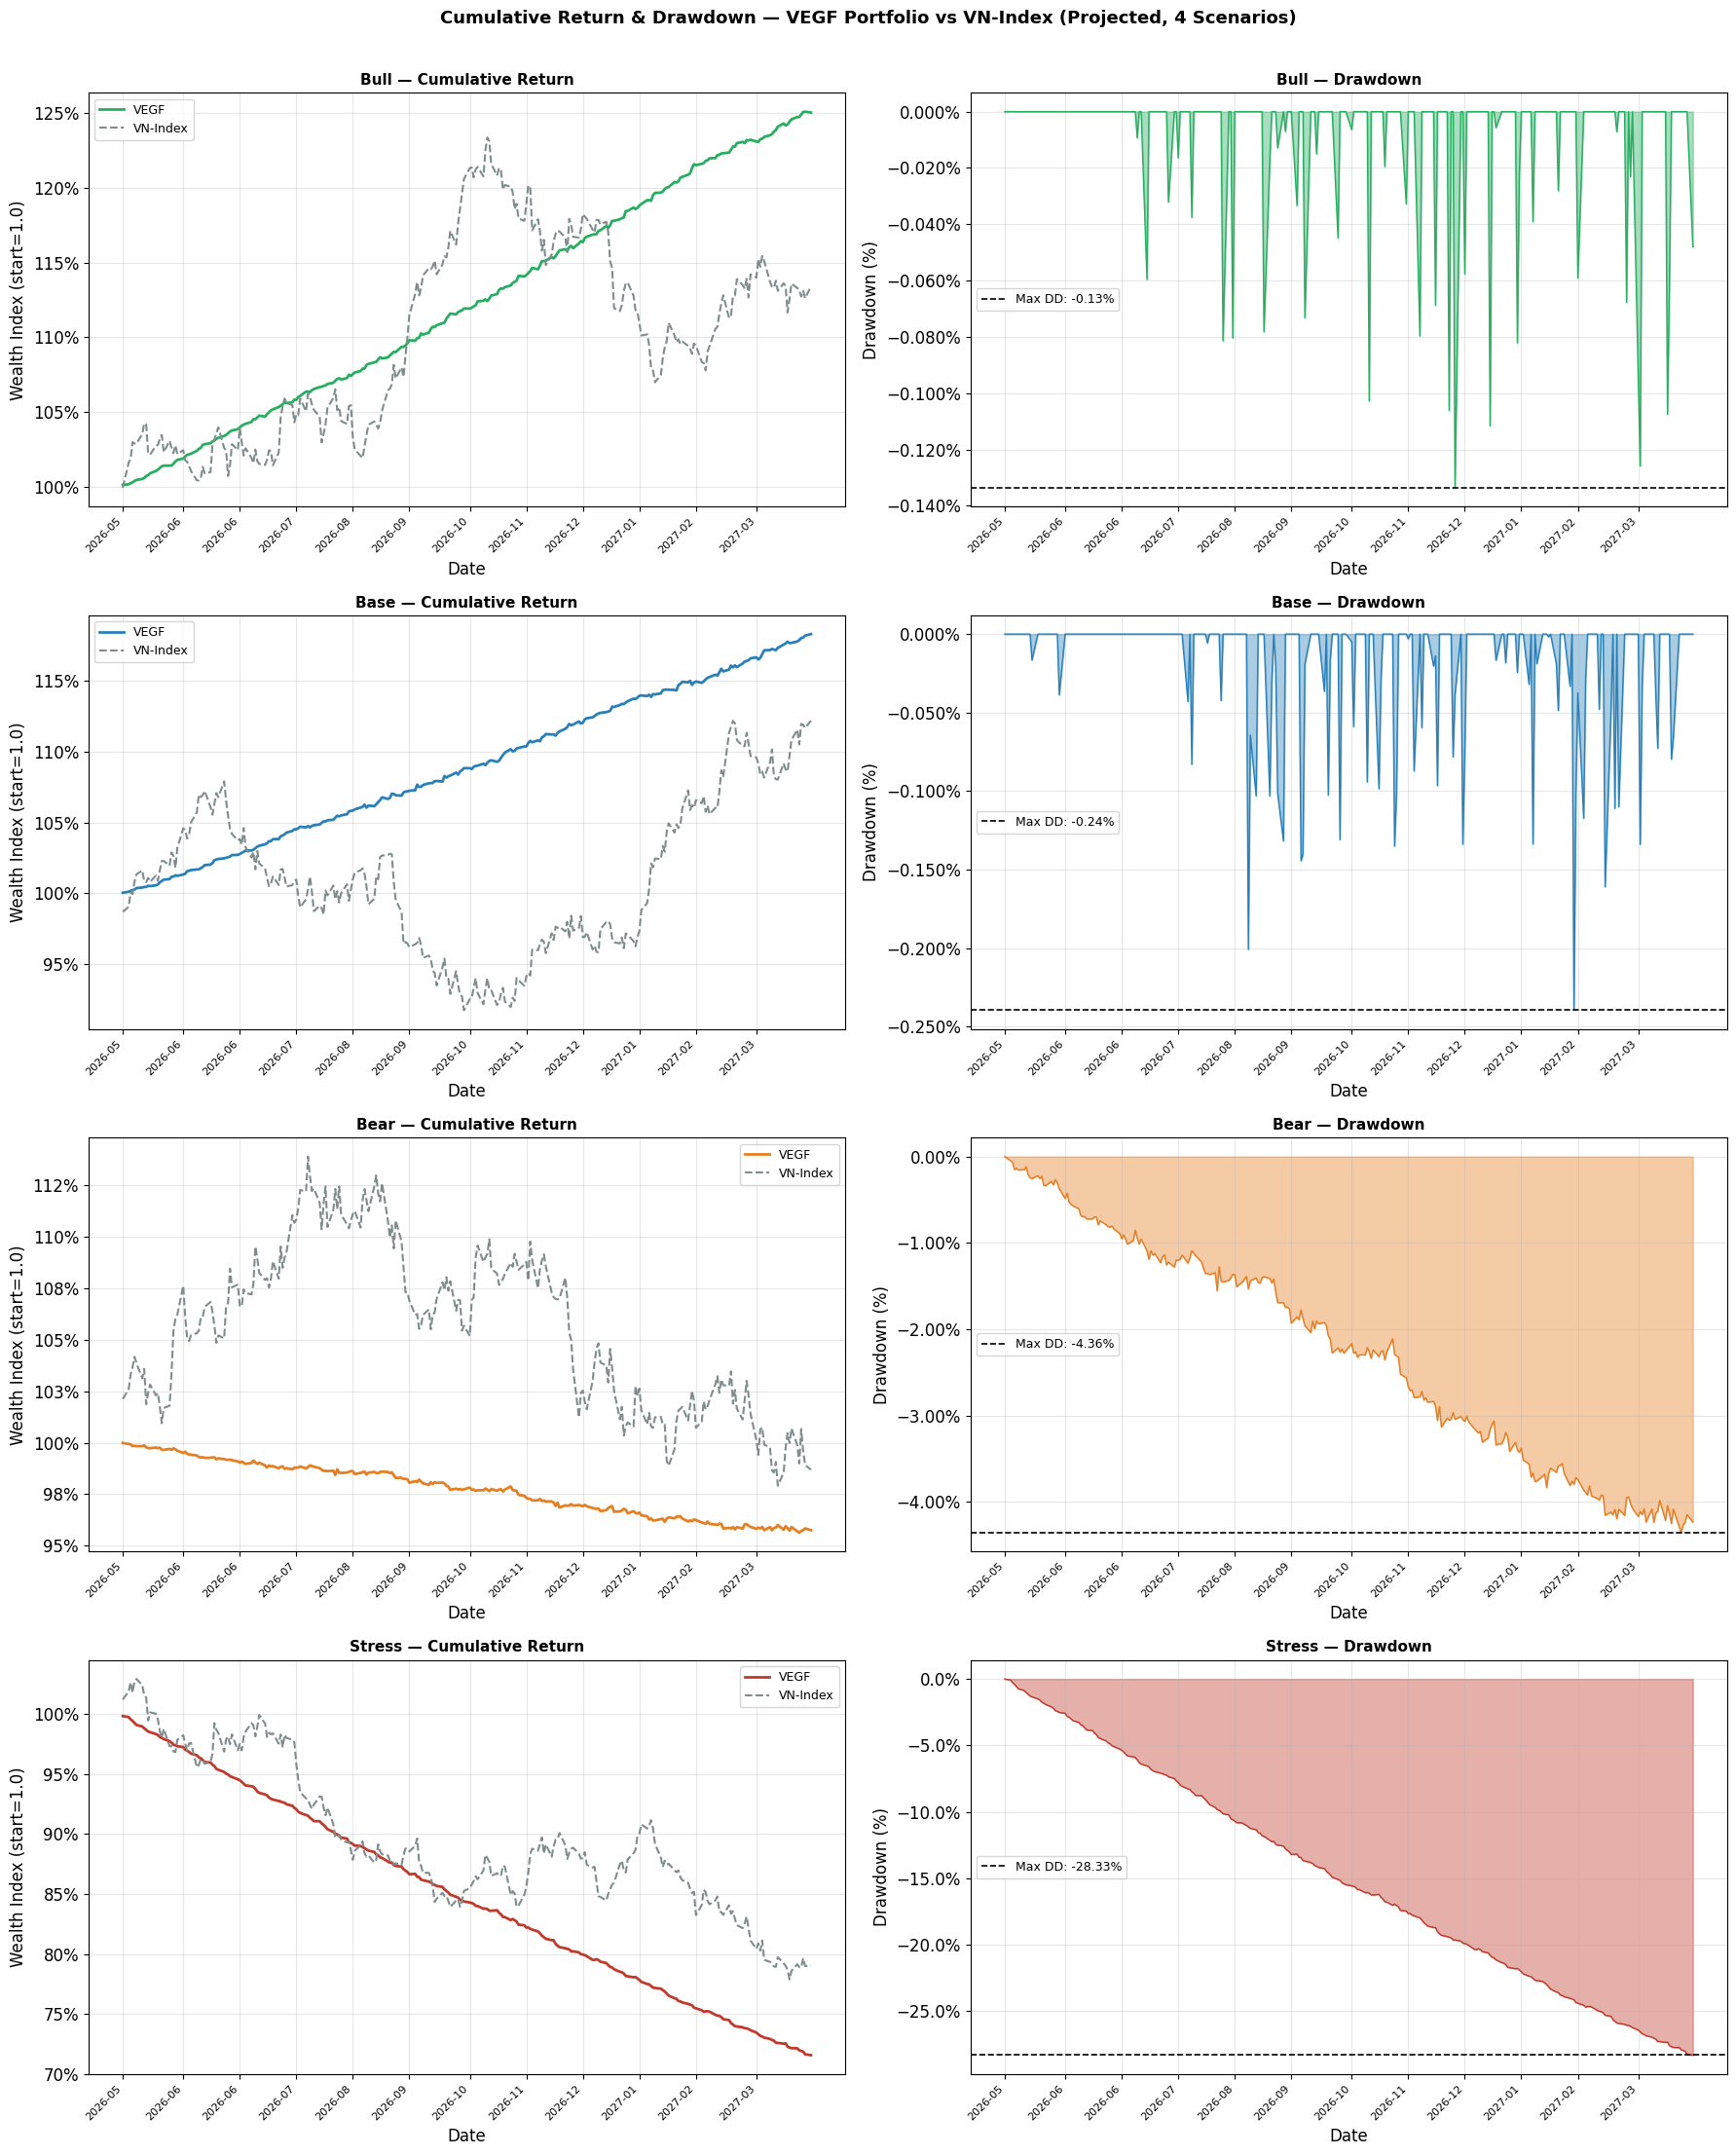

In [ ]:
# CHART: Cumulative Return + Drawdown
fig, axg = plt.subplots(4, 2, figsize=(18, 22))

dates = pd.bdate_range(start=MGMT_START_STR, periods=SIM_DAYS)

for i, (scen, cfg) in enumerate(SCENARIOS.items()):
    st     = stats_all[scen]
    port_d = st['port_d']
    bench_d= st['bench_d']

    cum_p  = np.cumprod(1 + port_d)
    cum_b  = np.cumprod(1 + bench_d)
    dd_p   = (cum_p - np.maximum.accumulate(cum_p)) / np.maximum.accumulate(cum_p)

    ax_l, ax_r = axg[i]

    # Cumulative Return Plot
    ax_l.plot(dates, cum_p, color=cfg['color'], lw=2, label='VEGF')
    ax_l.plot(dates, cum_b, color='#7F8C8D', lw=1.5, ls='--', label='VN-Index')
    ax_l.set_title(f'{scen} — Cumulative Return', fontsize=11, fontweight='bold')
    ax_l.set_ylabel('Wealth Index (start=1.0)')
    ax_l.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax_l.legend(fontsize=9); ax_l.grid(True, alpha=0.3)
    ax_l.set_xticks(dates[::21])
    ax_l.set_xticklabels([d.strftime('%Y-%m') for d in dates[::21]], rotation=45, ha='right', fontsize=8)
    ax_l.set_xlabel('Date')


    # Drawdown Plot
    ax_r.fill_between(dates, dd_p * 100, 0, color=cfg['color'], alpha=0.4)
    ax_r.plot(dates, dd_p * 100, color=cfg['color'], lw=1)
    ax_r.axhline(st['mdd'] * 100, color='black', ls='--', lw=1.2,
                 label=f"Max DD: {st['mdd']:.2%}")
    ax_r.set_title(f'{scen} — Drawdown', fontsize=11, fontweight='bold')
    ax_r.set_ylabel('Drawdown (%)'); ax_r.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_r.legend(fontsize=9); ax_r.grid(True, alpha=0.3)
    ax_r.set_xticks(dates[::21])
    ax_r.set_xticklabels([d.strftime('%Y-%m') for d in dates[::21]], rotation=45, ha='right', fontsize=8)
    ax_r.set_xlabel('Date')

plt.suptitle('Cumulative Return & Drawdown — VEGF Portfolio vs VN-Index (Projected, 4 Scenarios)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## **Attribution**

In [ ]:
# ATTRIBUTION SETUP
# VNI approximate sector weights (HOSE, mid-2026)
# https://finance.vietstock.vn/chi-so-nganh.htm
VNI_SECTOR_W = {
    'Financials': 0.4363,
    'Real Estate': 0.4138,
    'Materials': 0.0897,
    'Consumer Discretionary': 0.0602
}
total_vni_w = sum(VNI_SECTOR_W.values())
VNI_SECTOR_W = {k: v / total_vni_w for k, v in VNI_SECTOR_W.items()}

PORT_SECTOR_W = {}
for sector, tickers_s in tickers_dict.items():
    PORT_SECTOR_W[sector] = sum(ws_proj.get(t, 0) for t in tickers_s)

print("Attribution weights:")
print(f"  {'Sector':<28} {'Portfolio':>10} {'VNI':>10} {'Excess':>10}")
for sec in PORT_SECTOR_W:
    pw = PORT_SECTOR_W[sec]; iw = VNI_SECTOR_W.get(sec, 0)
    print(f"  {sec:<28} {pw:>10.2%} {iw:>10.2%} {pw-iw:>+10.2%}")

Attribution weights:
  Sector                        Portfolio        VNI     Excess
  Financials                       33.38%     43.63%    -10.25%
  Materials                        21.10%      8.97%    +12.13%
  Consumer Discretionary           14.74%      6.02%     +8.72%
  Real Estate                      30.78%     41.38%    -10.60%


In [ ]:
# ASSET CLASS ALLOCATION ANALYSIS
for scen in SCENARIOS:
    st = stats_all[scen]
    ann_r_b = st['ann_r_b']
    ann_r_p = st['ann_r_p']

    t2 = pd.DataFrame([
        {'Asset Class': 'Equity',
         'Portfolio Weight': f'{EQUITY_WEIGHT:.2%}', 'Index Weight': '100.00%',
         'Excess Weight': f'{EQUITY_WEIGHT-1:.2%}',
         'Index Return': f'{ann_r_b:.2%}',
         'Contribution': f'{(EQUITY_WEIGHT-1.0)*ann_r_b:.4%}'},
        {'Asset Class': 'Cash',
         'Portfolio Weight': f'{CASH_WEIGHT:.2%}', 'Index Weight': '0.00%',
         'Excess Weight': f'{CASH_WEIGHT:.2%}',
         'Index Return': f'{VN_RF:.2%}',
         'Contribution': f'{CASH_WEIGHT*VN_RF:.4%}'},
        {'Asset Class': 'TOTAL',
         'Portfolio Weight': '100.00%', 'Index Weight': '100.00%',
         'Excess Weight': '0.00%',
         'Index Return': f'{ann_r_b:.2%}',
         'Contribution': f'{EQUITY_WEIGHT*ann_r_p + CASH_WEIGHT*VN_RF:.2%}'},
    ]).set_index('Asset Class')

    print(f"\nTable 2 | Scenario: {scen}  |  {SCENARIOS[scen]['description'][:55]}")
    print("—" * 80)
    ipy_display(t2)



Table 2 | Scenario: Bull  |  GDP ≥7.5%; FTSE EM upgrade Sep/2026; record FDI; public
————————————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Asset Class,,,,,
Equity,90.00%,100.00%,-10.00%,13.33%,-1.3334%
Cash,10.00%,0.00%,10.00%,4.20%,0.4204%
TOTAL,100.00%,100.00%,0.00%,13.33%,25.85%



Table 2 | Scenario: Base  |  GDP ~7.8%; average CPI 4.8%; Brent USD 85–95; exchange 
————————————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Asset Class,,,,,
Equity,90.00%,100.00%,-10.00%,12.33%,-1.2334%
Cash,10.00%,0.00%,10.00%,4.20%,0.4204%
TOTAL,100.00%,100.00%,0.00%,12.33%,19.10%



Table 2 | Scenario: Bear  |  GDP <7%; Brent USD 100 → CPI 5.4%; SBV raises interest 
————————————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Asset Class,,,,,
Equity,90.00%,100.00%,-10.00%,-0.47%,0.0466%
Cash,10.00%,0.00%,10.00%,4.20%,0.4204%
TOTAL,100.00%,100.00%,0.00%,-0.47%,-1.49%



Table 2 | Scenario: Stress  |  Hormuz prolonged closure; Brent >110 USD; CPI >6%; fore
————————————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Asset Class,,,,,
Equity,90.00%,100.00%,-10.00%,-22.67%,2.2666%
Cash,10.00%,0.00%,10.00%,4.20%,0.4204%
TOTAL,100.00%,100.00%,0.00%,-22.67%,-23.73%


In [ ]:
# SECTOR ALLOCATION & STOCK SELECTION ANALYSIS
for scen in SCENARIOS:
    st      = stats_all[scen]
    ann_r_b = st['ann_r_b']

    rows = []
    for sector in PORT_SECTOR_W:
        pw  = PORT_SECTOR_W[sector]
        iw  = VNI_SECTOR_W.get(sector, 0.0)
        ew  = pw - iw
        ir  = sector_proj[scen].get(sector, ann_r_b)
        rows.append(
            {
                'Sector': sector,
                'Portfolio Weight': f'{pw:.2%}',
                'Index Weight'    : f'{iw:.2%}',
                'Excess Weight'   : f'{ew:.2%}',
                'Index Return'    : f'{ir:.2%}',
                'Contribution'    : f'{ew * ir:.4%}',
            }
        )

    t3 = pd.DataFrame(rows).set_index('Sector')
    print(f"\nTable 3 | Scenario: {scen}")
    print("—" * 72)
    ipy_display(t3)



Table 3 | Scenario: Bull
————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Sector,,,,,
Financials,33.38%,43.63%,-10.25%,28.56%,-2.9276%
Materials,21.10%,8.97%,12.13%,32.59%,3.9535%
Consumer Discretionary,14.74%,6.02%,8.72%,23.92%,2.0856%
Real Estate,30.78%,41.38%,-10.60%,19.64%,-2.0826%



Table 3 | Scenario: Base
————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Sector,,,,,
Financials,33.38%,43.63%,-10.25%,24.56%,-2.5176%
Materials,21.10%,8.97%,12.13%,24.09%,2.9222%
Consumer Discretionary,14.74%,6.02%,8.72%,18.92%,1.6497%
Real Estate,30.78%,41.38%,-10.60%,13.27%,-1.4067%



Table 3 | Scenario: Bear
————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Sector,,,,,
Financials,33.38%,43.63%,-10.25%,12.74%,-1.3056%
Materials,21.10%,8.97%,12.13%,-7.21%,-0.8752%
Consumer Discretionary,14.74%,6.02%,8.72%,3.67%,0.3200%
Real Estate,30.78%,41.38%,-10.60%,-11.56%,1.2251%



Table 3 | Scenario: Stress
————————————————————————————————————————————————————————————————————————


,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
Sector,,,,,
Financials,33.38%,43.63%,-10.25%,-6.81%,0.6983%
Materials,21.10%,8.97%,12.13%,-48.41%,-5.8736%
Consumer Discretionary,14.74%,6.02%,8.72%,-17.83%,-1.5546%
Real Estate,30.78%,41.38%,-10.60%,-46.48%,4.9278%


In [ ]:
# BHB SECTOR DECOMPOSITION (Allocation + Selection + Interaction)
import copy

for scen in SCENARIOS:
    st      = stats_all[scen]
    ann_r_b = st['ann_r_b']

    # Define explicit benchmark sector returns for each scenario
    benchmark_sector_proj = {}
    for sector_name in PORT_SECTOR_W.keys():
        if sector_name == 'Financials':
            benchmark_sector_proj[sector_name] = ann_r_b * 0.98
        elif sector_name == 'Materials':
            benchmark_sector_proj[sector_name] = ann_r_b * 1.05
        elif sector_name == 'Consumer Discretionary':
            benchmark_sector_proj[sector_name] = ann_r_b * 1.02
        elif sector_name == 'Real Estate':
            benchmark_sector_proj[sector_name] = ann_r_b * 0.95
        else:
            benchmark_sector_proj[sector_name] = ann_r_b

    rows = []
    for sector in PORT_SECTOR_W:
        pw      = PORT_SECTOR_W[sector]
        iw      = VNI_SECTOR_W.get(sector, 0.0)
        rp_s    = sector_proj[scen].get(sector, ann_r_b)
        ri_s    = benchmark_sector_proj.get(sector, ann_r_b)

        alloc   = (pw - iw) * (ri_s - ann_r_b)
        select  = iw * (rp_s - ri_s)
        interact= (pw - iw) * (rp_s - ri_s)
        total   = alloc + select + interact

        rows.append(
            {
                'Sector'             : sector,
                'Port. Weight'       : f'{pw:.2%}',
                'VNI Weight'         : f'{iw:.2%}',
                'Weights Diff'       : f'{pw-iw:.2%}',
                'Port. Sector Ret.'  : f'{rp_s:.2%}',
                'Index Ret.'         : f'{ri_s:.2%}',
                'Allocation Effect'  : f'{alloc:.4%}',
                'Selection Effect'   : f'{select:.4%}',
                'Interaction Effect' : f'{interact:.4%}',
                'Total Contribution' : f'{total:.4%}',
            }
        )

    t4 = pd.DataFrame(rows).set_index('Sector')
    print(f"\nTable 4 | Scenario: {scen}")
    print("—" * 100)
    ipy_display(t4)



Table 4 | Scenario: Bull
————————————————————————————————————————————————————————————————————————————————————————————————————


,Port. Weight,VNI Weight,Weights Diff,Port. Sector Ret.,Index Ret.,Allocation Effect,Selection Effect,Interaction Effect,Total Contribution
Sector,,,,,,,,,
Financials,33.38%,43.63%,-10.25%,28.56%,13.07%,0.0273%,6.7606%,-1.5882%,5.1997%
Materials,21.10%,8.97%,12.13%,32.59%,14.00%,0.0809%,1.6671%,2.2549%,4.0029%
Consumer Discretionary,14.74%,6.02%,8.72%,23.92%,13.60%,0.0233%,0.6212%,0.8998%,1.5442%
Real Estate,30.78%,41.38%,-10.60%,19.64%,12.67%,0.0707%,2.8870%,-0.7397%,2.2180%



Table 4 | Scenario: Base
————————————————————————————————————————————————————————————————————————————————————————————————————


,Port. Weight,VNI Weight,Weights Diff,Port. Sector Ret.,Index Ret.,Allocation Effect,Selection Effect,Interaction Effect,Total Contribution
Sector,,,,,,,,,
Financials,33.38%,43.63%,-10.25%,24.56%,12.09%,0.0253%,5.4429%,-1.2787%,4.1896%
Materials,21.10%,8.97%,12.13%,24.09%,12.95%,0.0748%,0.9989%,1.3510%,2.4247%
Consumer Discretionary,14.74%,6.02%,8.72%,18.92%,12.58%,0.0215%,0.3816%,0.5527%,0.9559%
Real Estate,30.78%,41.38%,-10.60%,13.27%,11.72%,0.0654%,0.6421%,-0.1645%,0.5430%



Table 4 | Scenario: Bear
————————————————————————————————————————————————————————————————————————————————————————————————————


,Port. Weight,VNI Weight,Weights Diff,Port. Sector Ret.,Index Ret.,Allocation Effect,Selection Effect,Interaction Effect,Total Contribution
Sector,,,,,,,,,
Financials,33.38%,43.63%,-10.25%,12.74%,-0.46%,-0.0010%,5.7566%,-1.3524%,4.4033%
Materials,21.10%,8.97%,12.13%,-7.21%,-0.49%,-0.0028%,-0.6032%,-0.8158%,-1.4218%
Consumer Discretionary,14.74%,6.02%,8.72%,3.67%,-0.48%,-0.0008%,0.2496%,0.3614%,0.6102%
Real Estate,30.78%,41.38%,-10.60%,-11.56%,-0.44%,-0.0025%,-4.5987%,1.1782%,-3.4229%



Table 4 | Scenario: Stress
————————————————————————————————————————————————————————————————————————————————————————————————————


,Port. Weight,VNI Weight,Weights Diff,Port. Sector Ret.,Index Ret.,Allocation Effect,Selection Effect,Interaction Effect,Total Contribution
Sector,,,,,,,,,
Financials,33.38%,43.63%,-10.25%,-6.81%,-22.21%,-0.0465%,6.7191%,-1.5785%,5.0942%
Materials,21.10%,8.97%,12.13%,-48.41%,-23.80%,-0.1375%,-2.2079%,-2.9863%,-5.3316%
Consumer Discretionary,14.74%,6.02%,8.72%,-17.83%,-23.12%,-0.0395%,0.3184%,0.4612%,0.7401%
Real Estate,30.78%,41.38%,-10.60%,-46.48%,-21.53%,-0.1201%,-10.3236%,2.6449%,-7.7988%


In [ ]:
# PERFORMANCE ATTRIBUTION SUMMARY
import copy

for scen in SCENARIOS:
    st      = stats_all[scen]
    ann_r_p = st['ann_r_p']
    ann_r_b = st['ann_r_b']

    total_alloc = total_select = total_inter = 0.0

    # Define explicit benchmark sector returns for each scenario
    benchmark_sector_proj_scen = {}
    for sector_name in PORT_SECTOR_W.keys():
        if sector_name == 'Financials':
            benchmark_sector_proj_scen[sector_name] = ann_r_b * 0.98
        elif sector_name == 'Materials':
            benchmark_sector_proj_scen[sector_name] = ann_r_b * 1.05
        elif sector_name == 'Consumer Discretionary':
            benchmark_sector_proj_scen[sector_name] = ann_r_b * 1.02
        elif sector_name == 'Real Estate':
            benchmark_sector_proj_scen[sector_name] = ann_r_b * 0.95
        else:
            benchmark_sector_proj_scen[sector_name] = ann_r_b

    for sector in PORT_SECTOR_W:
        pw   = PORT_SECTOR_W[sector]; iw = VNI_SECTOR_W.get(sector, 0.0)
        rp_s = sector_proj[scen].get(sector, ann_r_b)
        ri_s = benchmark_sector_proj_scen.get(sector, ann_r_b)

        alloc_val  = (pw - iw) * (ri_s - ann_r_b)
        select_val = iw * (rp_s - ri_s)
        inter_val  = (pw - iw) * (rp_s - ri_s)

        total_alloc  += alloc_val
        total_select += select_val
        total_inter  += inter_val

    asset_contrib  = (EQUITY_WEIGHT - 1.0) * ann_r_b
    active_return  = ann_r_p - ann_r_b

    t5 = pd.DataFrame([
        {'Attribution Factor': 'Benchmark Return (VN-Index)',
         'Return': f'{ann_r_b:.2%}', 'Weight': '—', 'Contribution': f'{ann_r_b:.2%}'},
        {'Attribution Factor': 'Asset Class Allocation',
         'Return': f'{ann_r_p:.2%}', 'Weight': f'{EQUITY_WEIGHT:.2%}', 'Contribution': f'{asset_contrib:.4%}'},
        {'Attribution Factor': 'Sector Allocation Effect',
         'Return': f'{total_alloc:.4%}', 'Weight': f'{EQUITY_WEIGHT:.2%}', 'Contribution': f'{total_alloc:.4%}'},
        {'Attribution Factor': 'Security Selection Effect',
         'Return': f'{total_select:.4%}', 'Weight': f'{EQUITY_WEIGHT:.2%}', 'Contribution': f'{total_select:.4%}'},
        {'Attribution Factor': 'Interaction Effect',
         'Return': f'{total_inter:.4%}', 'Weight': '—', 'Contribution': f'{total_inter:.4%}'},
        {'Attribution Factor': 'Total Active Return',
         'Return': f'{active_return:.4%}', 'Weight': '—', 'Contribution': f'{active_return:.4%}'},
        {'Attribution Factor': 'Portfolio Return',
         'Return': f'{ann_r_p:.2%}', 'Weight': '—', 'Contribution': f'{ann_r_p:.2%}'},
    ]).set_index('Attribution Factor')

    print(f"\nTable 5 | Scenario: {scen}")
    print("—" * 68)
    ipy_display(t5)



Table 5 | Scenario: Bull
————————————————————————————————————————————————————————————————————


,Return,Weight,Contribution
Attribution Factor,,,
Benchmark Return (VN-Index),13.33%,—,13.33%
Asset Class Allocation,28.25%,90.00%,-1.3334%
Sector Allocation Effect,0.2022%,90.00%,0.2022%
Security Selection Effect,11.9359%,90.00%,11.9359%
Interaction Effect,0.8268%,—,0.8268%
Total Active Return,14.9166%,—,14.9166%
Portfolio Return,28.25%,—,28.25%



Table 5 | Scenario: Base
————————————————————————————————————————————————————————————————————


,Return,Weight,Contribution
Attribution Factor,,,
Benchmark Return (VN-Index),12.33%,—,12.33%
Asset Class Allocation,20.76%,90.00%,-1.2334%
Sector Allocation Effect,0.1870%,90.00%,0.1870%
Security Selection Effect,7.4655%,90.00%,7.4655%
Interaction Effect,0.4606%,—,0.4606%
Total Active Return,8.4250%,—,8.4250%
Portfolio Return,20.76%,—,20.76%



Table 5 | Scenario: Bear
————————————————————————————————————————————————————————————————————


,Return,Weight,Contribution
Attribution Factor,,,
Benchmark Return (VN-Index),-0.47%,—,-0.47%
Asset Class Allocation,-2.12%,90.00%,0.0466%
Sector Allocation Effect,-0.0071%,90.00%,-0.0071%
Security Selection Effect,0.8043%,90.00%,0.8043%
Interaction Effect,-0.6285%,—,-0.6285%
Total Active Return,-1.6574%,—,-1.6574%
Portfolio Return,-2.12%,—,-2.12%



Table 5 | Scenario: Stress
————————————————————————————————————————————————————————————————————


,Return,Weight,Contribution
Attribution Factor,,,
Benchmark Return (VN-Index),-22.67%,—,-22.67%
Asset Class Allocation,-26.84%,90.00%,2.2666%
Sector Allocation Effect,-0.3436%,90.00%,-0.3436%
Security Selection Effect,-5.4940%,90.00%,-5.4940%
Interaction Effect,-1.4586%,—,-1.4586%
Total Active Return,-4.1727%,—,-4.1727%
Portfolio Return,-26.84%,—,-26.84%


## **Risk Management Impact Summary**

In [ ]:
# RISK MANAGEMENT IMPACT SUMMARY
from IPython.display import display as ipy_display

rm_summary_rows = []
for scen in SCENARIOS:
    wm_rm_s, wm_base_s, trig_s = simulate_nav_emergency(
        scen, n_paths=500, random_seed=99)
    final_rm_s   = wm_rm_s[-1, :]   - 1
    final_base_s = wm_base_s[-1, :] - 1

    med_rm_s   = np.median(wm_rm_s,   axis=1)
    med_base_s = np.median(wm_base_s, axis=1)
    mdd_rm_s   = ((med_rm_s   - np.maximum.accumulate(med_rm_s))   /
                  np.maximum.accumulate(med_rm_s)).min()
    mdd_base_s = ((med_base_s - np.maximum.accumulate(med_base_s)) /
                  np.maximum.accumulate(med_base_s)).min()

    pct_trig_s = float(np.sum(~np.isnan(trig_s))) / len(trig_s)

    rm_summary_rows.append({
        'Scenario'                  : scen,
        'Prob'                      : f"{SCENARIOS[scen]['prob']:.0%}",
        '% Paths Kích Hoạt RM'     : f"{pct_trig_s:.1%}",
        'Median Return (CÓ RM)'    : f"{np.median(final_rm_s):.2%}",
        'Median Return (KHÔNG RM)' : f"{np.median(final_base_s):.2%}",
        'Lợi Ích Bảo Vệ'          : f"{np.median(final_rm_s)-np.median(final_base_s):+.2%}",
        'VaR 95% (CÓ RM)'         : f"{np.percentile(final_rm_s, 5):.2%}",
        'VaR 95% (KHÔNG RM)'      : f"{np.percentile(final_base_s, 5):.2%}",
        'MDD (CÓ RM)'             : f"{mdd_rm_s:.2%}",
        'MDD (KHÔNG RM)'          : f"{mdd_base_s:.2%}",
        'Giảm Thiểu MDD'          : f"{mdd_rm_s - mdd_base_s:+.2%}",
    })

rm_df = pd.DataFrame(rm_summary_rows).set_index('Scenario')
print('Risk Management Impact Summary — 4 Scenarios (01/05/2026–01/05/2027)')
print('=' * 120)
ipy_display(rm_df)
print()
print('Quy tắc áp dụng:')
print(f'  • Stop-Loss -7%  : Bán 50% vị thế → cắt lỗ nhẹ, giữ lại 50% tiềm năng phục hồi')
print(f'  • Stop-Loss -10% : Bán 100% vị thế → chấp nhận sai, bảo toàn vốn còn lại')
print(f'  • NAV Emergency  : NAV -10% → bán hạ tỷ trọng, Cash {EMERGENCY_CASH_TARGET*100:.0f}% equity '
      f'→ Gov Bond {GOVBOND_RATE*100:.0f}%/năm tới hết kỳ')


Risk Management Impact Summary — 4 Scenarios (01/05/2026–01/05/2027)


,Prob,% Paths Kích Hoạt RM,Median Return (CÓ RM),Median Return (KHÔNG RM),Lợi Ích Bảo Vệ,VaR 95% (CÓ RM),VaR 95% (KHÔNG RM),MDD (CÓ RM),MDD (KHÔNG RM),Giảm Thiểu MDD
Scenario,,,,,,,,,,
Bull,25%,26.6%,21.73%,25.53%,-3.79%,-6.45%,-10.92%,-1.22%,-0.94%,-0.28%
Base,50%,34.4%,14.30%,18.38%,-4.08%,-8.83%,-16.00%,-1.16%,-1.01%,-0.15%
Bear,20%,63.4%,-4.75%,-3.64%,-1.11%,-12.13%,-31.64%,-5.47%,-4.17%,-1.30%
Stress,5%,94.0%,-10.95%,-28.12%,+17.17%,-15.87%,-49.03%,-10.98%,-28.31%,+17.33%



Quy tắc áp dụng:
  • Stop-Loss -7%  : Bán 50% vị thế → cắt lỗ nhẹ, giữ lại 50% tiềm năng phục hồi
  • Stop-Loss -10% : Bán 100% vị thế → chấp nhận sai, bảo toàn vốn còn lại
  • NAV Emergency  : NAV -10% → bán hạ tỷ trọng, Cash 70% equity → Gov Bond 11%/năm tới hết kỳ


## **Style Analysis**

In [ ]:
# FUND PERFORMANCE DECOMPOSITION
rows_t6 = []
for scen in SCENARIOS:
    st = stats_all[scen]
    bench_comp  = st['beta'] * (st['ann_r_b'] - VN_RF) + VN_RF
    select_comp = st['ann_r_p'] - bench_comp
    rows_t6.append({
        'Scenario'            : scen,
        'Fund Return'         : f"{st['ann_r_p']:.2%}",
        'Benchmark Component' : f"{bench_comp:.2%}",
        'Selection Component' : f"{select_comp:.2%}",
        'Tracking Error'      : f"{st['te']:.2%}",
        'Beta Weight'         : f"{st['beta']:.4f}",
        'Selection Weight'    : f"{1.0-st['beta']:.4f}",
        'Info Ratio'          : f"{st['ir']:.4f}",
        'Active Return'       : f"{st['ann_r_p']-st['ann_r_b']:.2%}",
    })

t6 = pd.DataFrame(rows_t6).set_index('Scenario')
print("Table 6: Fund Performance Decomposition (Style Analysis) — 4 Scenarios")
print("=" * 100)
ipy_display(t6)


Table 6: Fund Performance Decomposition (Style Analysis) — 4 Scenarios


,Fund Return,Benchmark Component,Selection Component,Tracking Error,Beta Weight,Selection Weight,Info Ratio,Active Return
Scenario,,,,,,,,
Bull,28.25%,4.22%,24.03%,12.34%,0.0023,0.9977,0.7320,14.92%
Base,20.76%,4.19%,16.57%,13.05%,-0.0023,1.0023,0.3430,8.42%
Bear,-2.12%,4.21%,-6.34%,13.18%,-0.0021,1.0021,-0.2931,-1.66%
Stress,-26.84%,4.08%,-30.92%,13.00%,0.0045,0.9955,-0.8283,-4.17%


### Chart: Rolling Beta, Tracking Error & Information Ratio (Base Scenario)

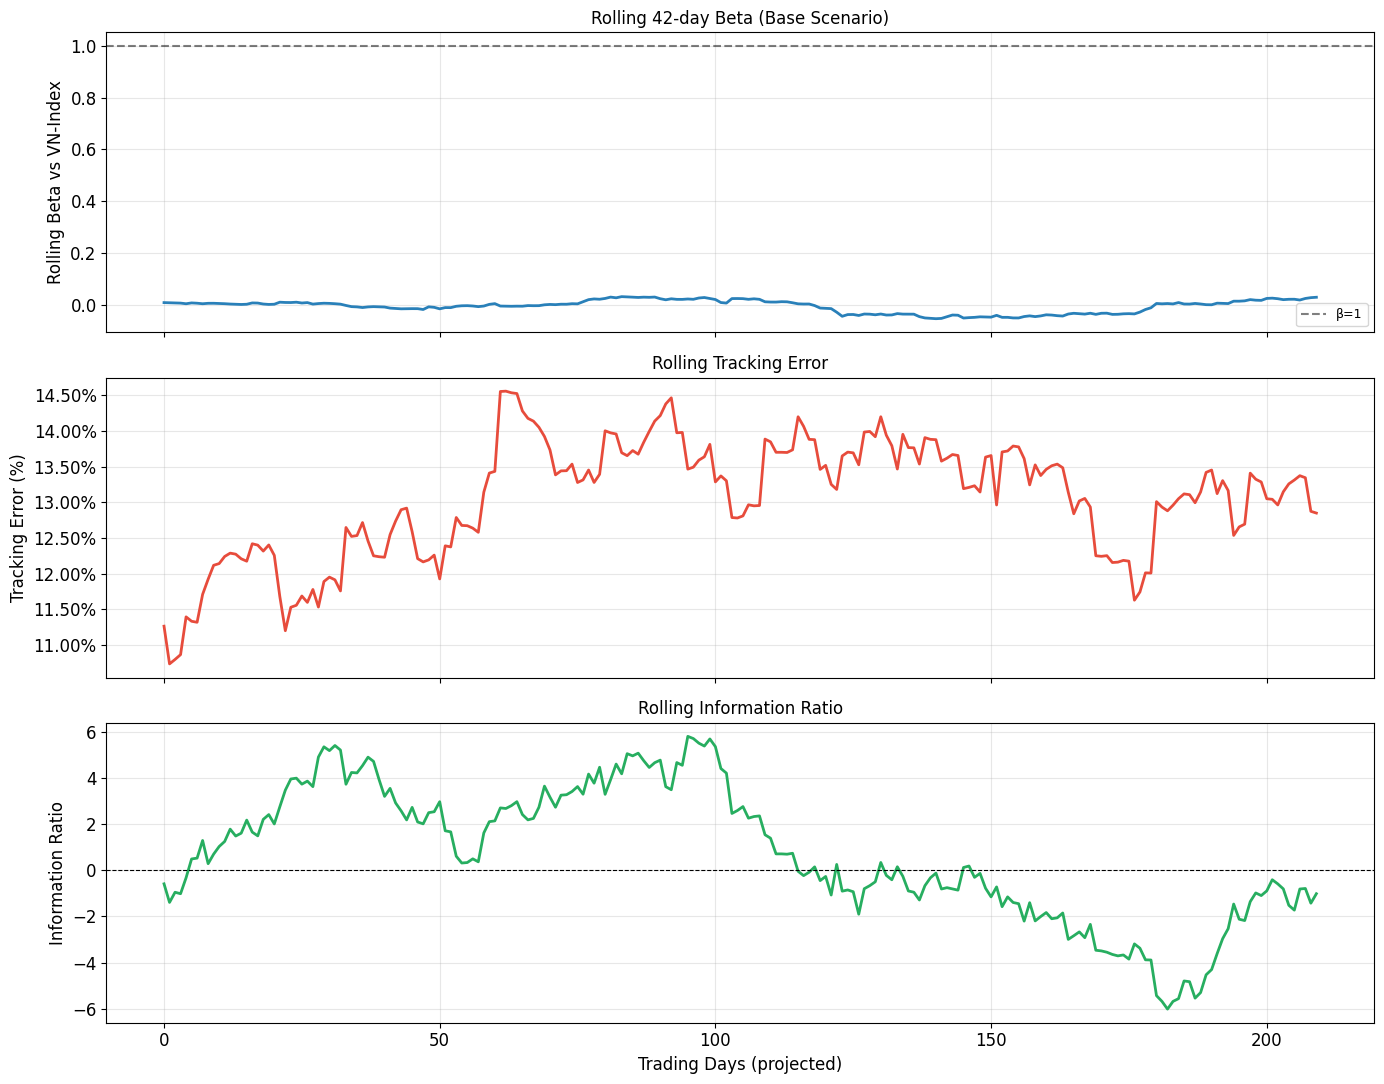

In [ ]:
# ROLLING STATS CHART — Base Scenario (projected)
ROLL_W = 42

st_base = stats_all['Base']
pd_b    = st_base['port_d']
bd_b    = st_base['bench_d']
rf_d    = VN_RF / TRADING_DAYS

roll_beta, roll_te, roll_ir = [], [], []
for end in range(ROLL_W, len(pd_b)):
    sl_p = pd_b[end-ROLL_W:end]
    sl_b = bd_b[end-ROLL_W:end]
    b_   = np.cov(sl_p - rf_d, sl_b - rf_d)[0,1] / np.var(sl_b - rf_d) if np.var(sl_b) > 0 else 1.0
    act  = sl_p - sl_b
    te_  = act.std() * np.sqrt(TRADING_DAYS)
    ir_  = (act.mean() * TRADING_DAYS) / te_ if te_ > 0 else np.nan
    roll_beta.append(b_); roll_te.append(te_); roll_ir.append(ir_)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ax1.plot(roll_beta, color='#2980B9', lw=2)
ax1.axhline(1.0, color='black', ls='--', alpha=0.5, label='β=1')
ax1.set_ylabel('Rolling Beta vs VN-Index'); ax1.set_title(f'Rolling {ROLL_W}-day Beta (Base Scenario)', fontsize=12)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.plot([t*100 for t in roll_te], color='#E74C3C', lw=2)
ax2.set_ylabel('Tracking Error (%)'); ax2.set_title('Rolling Tracking Error', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter()); ax2.grid(True, alpha=0.3)

ax3.plot(roll_ir, color='#27AE60', lw=2)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.set_ylabel('Information Ratio'); ax3.set_title('Rolling Information Ratio', fontsize=12)
ax3.set_xlabel('Trading Days (projected)'); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


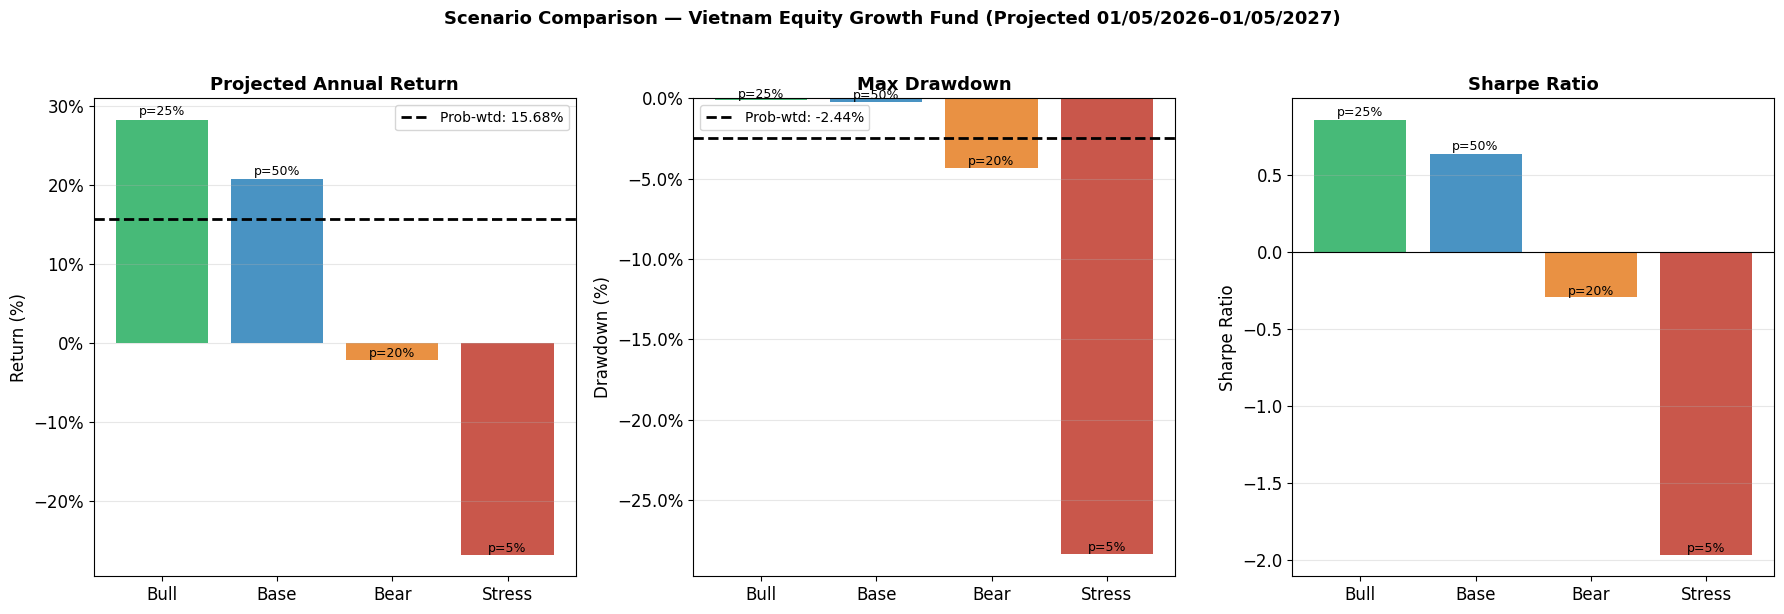


Final Probability-Weighted Summary
────────────────────────────────────────────────────────────


,Prob,Proj. Return,MC Ann. Return,Volatility,Sharpe,MDD,Jensen's α,IR
Scenario,,,,,,,,
Bull,25%,25.76%,28.25%,28.15%,0.8543,-0.13%,18.14%,0.7320
Base,50%,19.89%,20.76%,26.24%,0.6309,-0.24%,12.63%,0.3430
Bear,20%,-0.69%,-2.12%,21.26%,-0.2976,-4.36%,-8.54%,-0.2931
Stress,5%,-29.97%,-26.84%,15.78%,-1.9666,-28.33%,-37.52%,-0.8283
Prob-Wtd,100%,15.68%,—,—,—,-2.44%,—,—


In [ ]:
# SCENARIO COMPARISON CHART
scen_names  = list(SCENARIOS.keys())
colors_     = [SCENARIOS[s]['color'] for s in scen_names]
returns_ann = [stats_all[s]['ann_r_p']  for s in scen_names]
mdds_       = [stats_all[s]['mdd']      for s in scen_names]
sharpes_    = [stats_all[s]['sharpe_p'] for s in scen_names]
probs_      = [SCENARIOS[s]['prob']     for s in scen_names]

prob_wtd_r  = sum(p*r for p,r in zip(probs_, returns_ann))
prob_wtd_m  = sum(p*m for p,m in zip(probs_, mdds_))

fig, axes_sc = plt.subplots(1, 3, figsize=(18, 6))

axes_sc[0].bar(scen_names, [r*100 for r in returns_ann], color=colors_, alpha=0.85)
axes_sc[0].axhline(prob_wtd_r*100, color='black', ls='--', lw=2, label=f'Prob-wtd: {prob_wtd_r:.2%}')
axes_sc[0].set_title('Projected Annual Return', fontsize=13, fontweight='bold')
axes_sc[0].set_ylabel('Return (%)'); axes_sc[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes_sc[0].legend(fontsize=10); axes_sc[0].grid(axis='y', alpha=0.3)

axes_sc[1].bar(scen_names, [m*100 for m in mdds_], color=colors_, alpha=0.85)
axes_sc[1].axhline(prob_wtd_m*100, color='black', ls='--', lw=2, label=f'Prob-wtd: {prob_wtd_m:.2%}')
axes_sc[1].set_title('Max Drawdown', fontsize=13, fontweight='bold')
axes_sc[1].set_ylabel('Drawdown (%)'); axes_sc[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes_sc[1].legend(fontsize=10); axes_sc[1].grid(axis='y', alpha=0.3)

axes_sc[2].bar(scen_names, sharpes_, color=colors_, alpha=0.85)
axes_sc[2].axhline(0, color='black', lw=0.8)
axes_sc[2].set_title('Sharpe Ratio', fontsize=13, fontweight='bold')
axes_sc[2].set_ylabel('Sharpe Ratio'); axes_sc[2].grid(axis='y', alpha=0.3)

for ax in axes_sc:
    for j, (rect, p) in enumerate(zip(ax.patches, probs_)):
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height()*1.01 if rect.get_height()>0 else rect.get_height()-0.003,
                f'p={p:.0%}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Scenario Comparison — Vietnam Equity Growth Fund (Projected 01/05/2026–01/05/2027)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Final probability-weighted summary table
print("\nFinal Probability-Weighted Summary")
print("─" * 60)
final_rows = []
for s in SCENARIOS:
    st = stats_all[s]
    final_rows.append({
        'Scenario'       : s,
        'Prob'           : f"{SCENARIOS[s]['prob']:.0%}",
        'Proj. Return'   : f"{port_proj_annual[s]:.2%}",
        'MC Ann. Return' : f"{st['ann_r_p']:.2%}",
        'Volatility'     : f"{st['ann_std_p']:.2%}",
        'Sharpe'         : f"{st['sharpe_p']:.4f}",
        'MDD'            : f"{st['mdd']:.2%}",
        "Jensen's α"     : f"{st['alpha_ann']:.2%}",
        'IR'             : f"{st['ir']:.4f}",
    })
final_rows.append({
    'Scenario': 'Prob-Wtd', 'Prob': '100%',
    'Proj. Return': f'{prob_wtd_r:.2%}', 'MC Ann. Return': '—',
    'Volatility': '—', 'Sharpe': '—', 'MDD': f'{prob_wtd_m:.2%}',
    "Jensen's α": '—', 'IR': '—',
})
ipy_display(pd.DataFrame(final_rows).set_index('Scenario'))
